# MLP Ablations

Open-ended ablation program testing whether anything beats the standing baseline MLP, batch size recheck, feature swaps, architecture capacity/depth, feature design, and the split-choice noise floor every comparison here is judged against. Foundational, settled decisions (class taxonomy, bin count, baseline train/eval) live in `mlp_classifier.ipynb`; this notebook is for open questions, not settled ones, and keeps growing as new ideas get tested.


## Headline findings

Two things here actually matter, everything else is a ruled-out ablation kept for the record. Full ranked takeaways: `MLP_Decisions_and_Findings.md`, Summary section.

1. **Sparsity is the ceiling, not the model or the features.** Point count diagnostic below: macro F1 roughly doubles from 1 to 5 points/instance (0.381 -> 0.764) on the same trained model, no retraining.
2. **`combined_features` is the one validated positive result.** Stacking every feature tried in this program gives +0.036 macro F1, validated across all 6 splits (wins every fold). About a tenth the size of finding 1, concentrated in `two_wheeler`/`pedestrian_group`, doesn't touch `large_vehicle`.

Everything between here and there (capacity, depth, point count as a feature, orientation features, explicit statistics, bin edge placement) landed inside the split-choice noise floor established early on, kept here for the record, not because any of them individually go anywhere. Skip ahead if you just want the two findings above.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from taxonomy_separability import add_relative_features
from mlp_classifier import apply_mlp_class_groups
from mlp_variants import run_variant
from split_sensitivity import run_split_sensitivity


In [2]:
df = build_and_save_points_table()
df = add_relative_features(df)
df = apply_mlp_class_groups(df)


/home/bruno/radar_machine_learning_ws/results/data/points_table.parquet already covers exactly the requested sequences, skipping build


Baseline reference (cached, no retraining), every comparison below is measured against this.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_precision_recall_f1.png


,precision,recall,f1,support
car,0.937115,0.784093,0.853802,31055
large_vehicle,0.719491,0.796542,0.756059,6247
two_wheeler,0.475302,0.544610,0.507601,4629
pedestrian,0.533806,0.943929,0.681956,11325
pedestrian_group,0.754346,0.544238,0.632295,17858


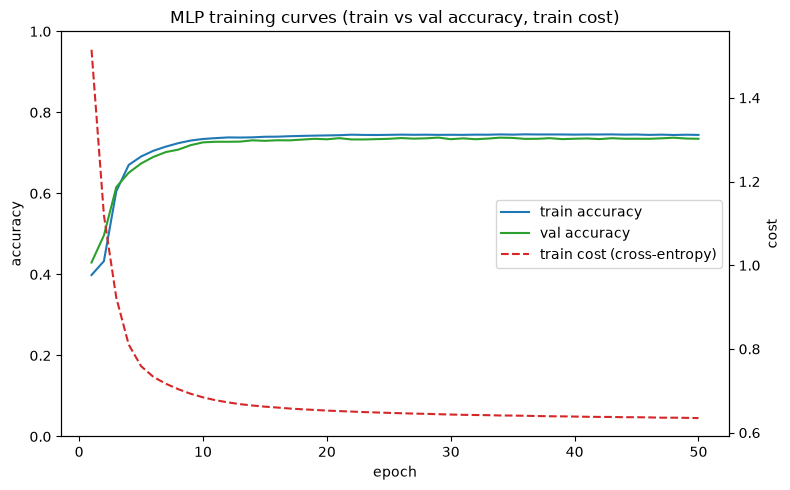

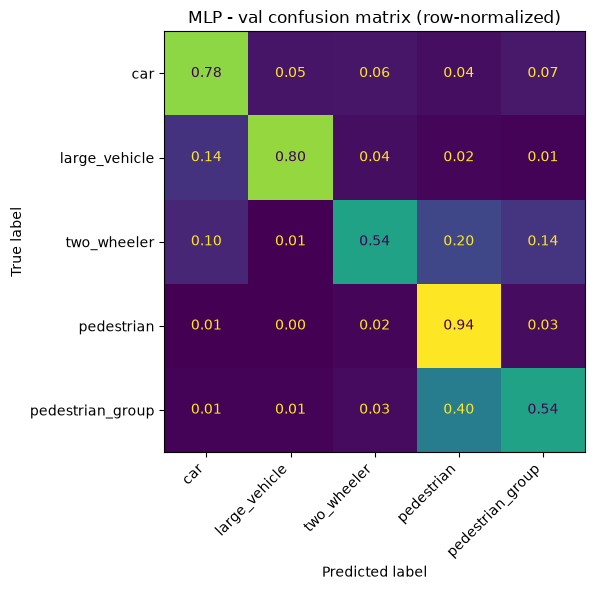

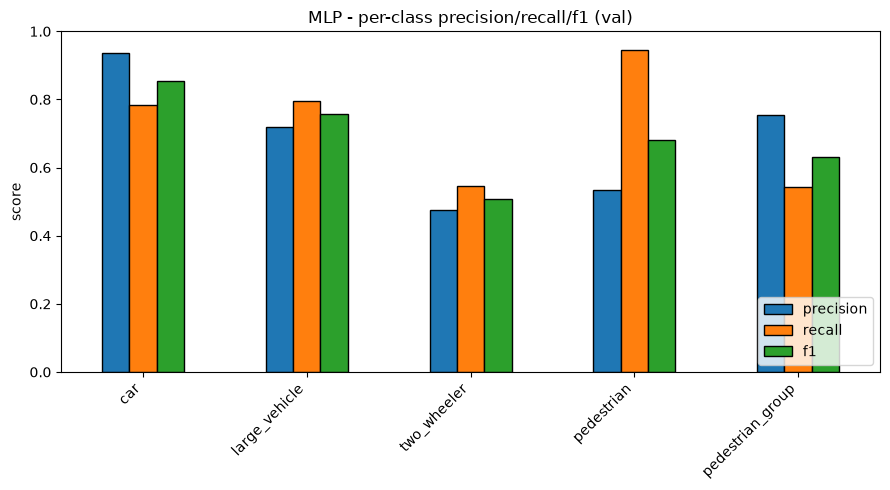

In [3]:
_, _, baseline_metrics, _, _ = run_variant(df, "baseline")
baseline_metrics


## Feature swap: range_sc

Same architecture/training config as `baseline`, but `range_sc` (per point sensor range) binned into the same N_BINS=16 columns used for `rcs`/`vr_compensated`/`x_rel`/`y_rel`, instead of `doppler_spread` appended unbinned. `bs32` separately rechecks `BATCH_SIZE`/`LEARNING_RATE` now that bus, the original binding constraint, is merged into `large_vehicle`. Both defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.771  0.847    31055
large_vehicle         0.655   0.797  0.719     6247
two_wheeler           0.501   0.641  0.563     4629
pedestrian            0.590   0.861  0.700    11325
pedestrian_group      0.743   0.648  0.692    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/range_sc/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.782  0.852    31055
large_vehicle         0.717   0.791  0.753     6247
two_wheeler           0.488   0.541  0.513     4629
pedestrian            0.540   0.934  0.684    11325
pedestrian_group      0.731   0.555  0.631    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/bs32/mlp_precision_recall_f1.png


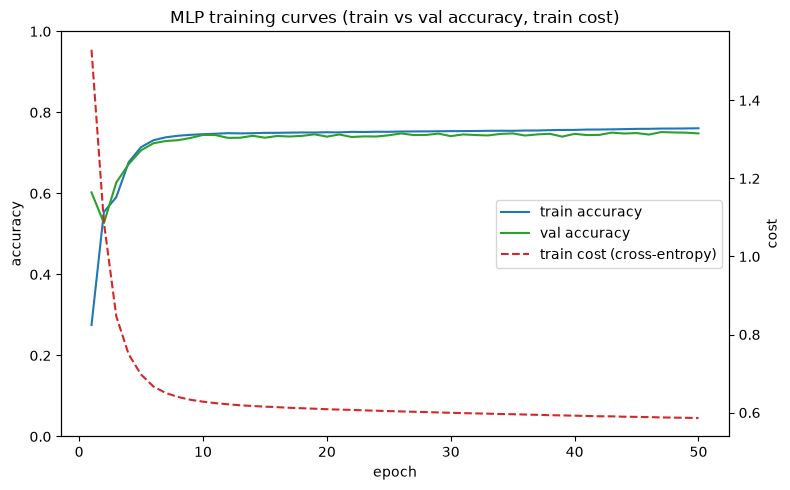

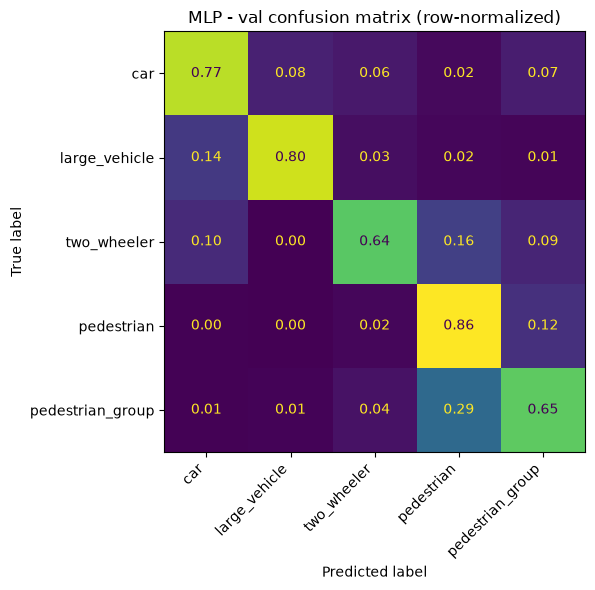

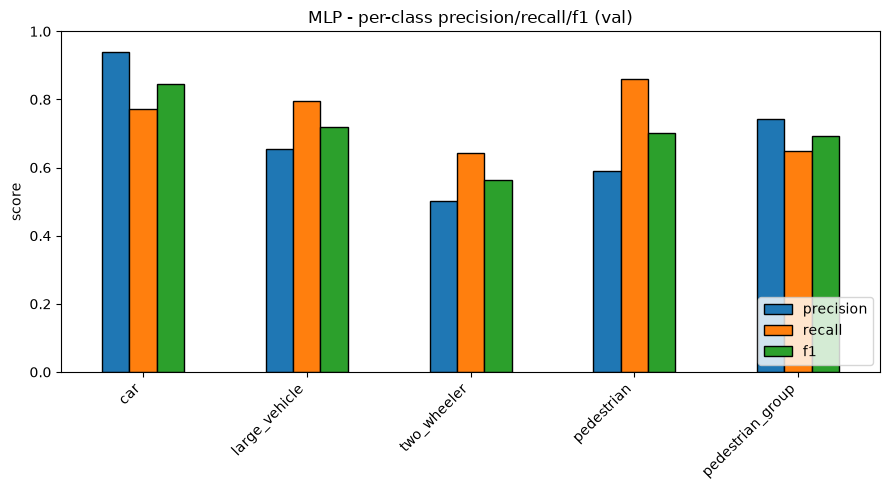

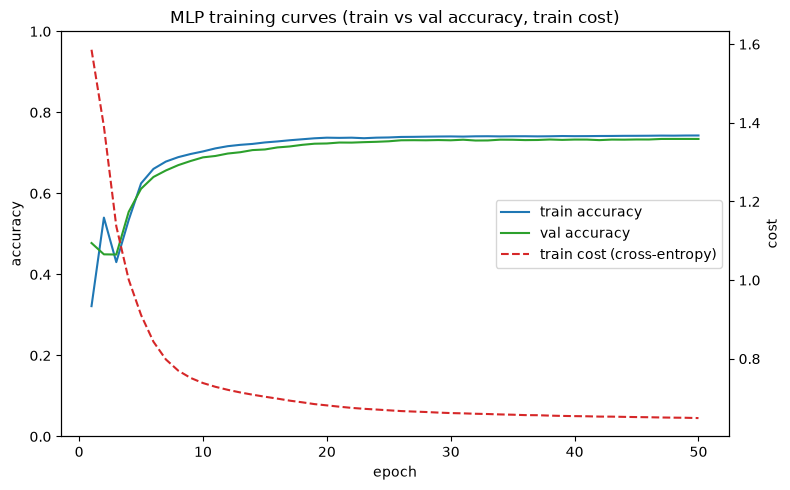

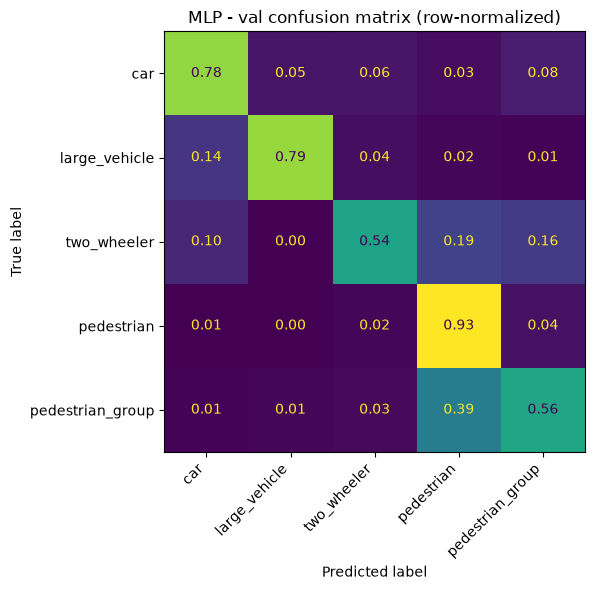

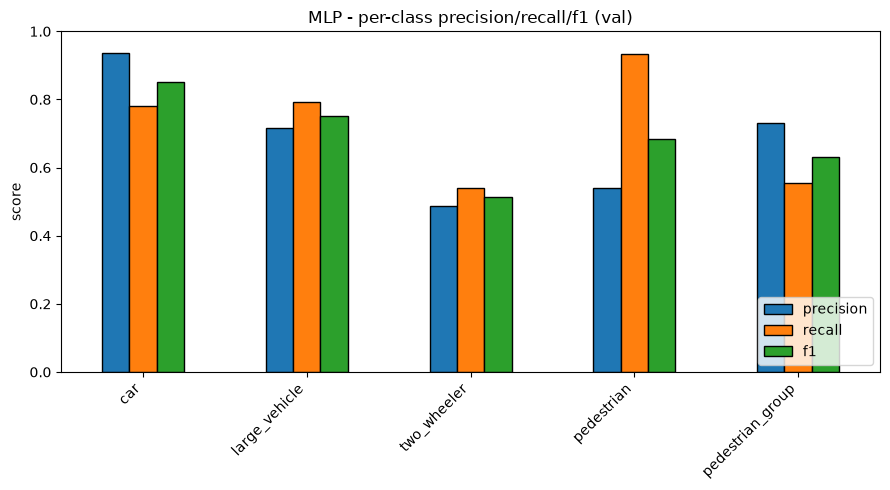

In [4]:
# both cached, no retraining
_, _, range_sc_metrics, _, _ = run_variant(df, "range_sc")
_, _, bs32_metrics, _, _ = run_variant(df, "bs32")

In [5]:
range_sc_metrics

,precision,recall,f1,support
car,0.939141,0.770697,0.846622,31055
large_vehicle,0.654914,0.796862,0.718949,6247
two_wheeler,0.501182,0.641391,0.562684,4629
pedestrian,0.590084,0.860662,0.700140,11325
pedestrian_group,0.742590,0.648113,0.692142,17858


In [6]:
bs32_metrics

,precision,recall,f1,support
car,0.936661,0.781903,0.852314,31055
large_vehicle,0.717458,0.791420,0.752626,6247
two_wheeler,0.488204,0.540938,0.513220,4629
pedestrian,0.539525,0.934128,0.683994,11325
pedestrian_group,0.731161,0.555269,0.631190,17858


Macro F1: `baseline` 0.686, `range_sc` 0.704, `bs32` 0.687. `range_sc` initially looked better, but see the split sensitivity check below: that gap is within normal split-to-split noise, not a real improvement. `bs32` is essentially identical to `baseline`, `BATCH_SIZE=128` stays.

Full writeup: `MLP_Decisions_and_Findings.md` section 5.

## Split sensitivity check

Is a macro F1 difference like `range_sc`'s (0.018 vs `baseline`) real, or just noise from which sequences happen to land in val? Tried picking a "better" val set by generating the 6 distinct valid splits at the fixed 70/15/15 proportions and scoring each by how closely train and val's per-class feature distributions matched (two-sample Kolmogorov-Smirnov statistic), then trained `baseline`'s exact config on all 6.

`scripts/split_sensitivity.py`, results at `results/mlp/split_search/fold_<n>/`.

 random_state  fold  n_val_sequences  mean_ks  max_ks
            0     0               22   0.0557  0.1793
            1     0               22   0.0557  0.1793
            2     0               22   0.0557  0.1793
            3     0               22   0.0557  0.1793
            4     0               22   0.0557  0.1793
            5     0               22   0.0557  0.1793
            6     0               22   0.0557  0.1793
            7     0               22   0.0557  0.1793
            8     0               22   0.0557  0.1793
            9     0               22   0.0557  0.1793
            0     2               19   0.0588  0.2857
            1     2               19   0.0588  0.2857
            2     2               19   0.0588  0.2857
            3     2               19   0.0588  0.2857
            4     2               19   0.0588  0.2857
            5     2               19   0.0588  0.2857
            6     2               19   0.0588  0.2857
            7     2         

/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.930   0.807  0.864    31363
large_vehicle         0.726   0.709  0.717     6243
two_wheeler           0.474   0.753  0.582     4720
pedestrian            0.502   0.915  0.648    11074
pedestrian_group      0.781   0.465  0.583    18757
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_0/mlp_precision_recall_f1.png
fold 0 macro F1: 0.6788
=== fold 1 (max_ks=0.6238) ===


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_1/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_1/mlp_training_curves.png


...

Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_4/mlp_precision_recall_f1.png
fold 4 macro F1: 0.6953
=== fold 5 (max_ks=0.2870) ===


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.949   0.812  0.875    29555
large_vehicle         0.764   0.866  0.812     6312
two_wheeler           0.405   0.669  0.505     4831
pedestrian            0.538   0.919  0.679    11605
pedestrian_group      0.805   0.443  0.572    17668
Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/split_search/fold_5/mlp_precision_recall_f1.png
fold 5 macro F1: 0.6884

macro F1 range: 0.651 - 0.734, std: 0.027
 fold   max_ks  macro_f1
    0 0.179348  0.678828
    1 0.623832  0.734235
    2 0.285685  0.700931
    3 0.336050  0.651298
    4 0.286753  0.695262
    5 0.287041  0.688433


,fold,max_ks,macro_f1
0,0,0.179348,0.678828
1,1,0.623832,0.734235
2,2,0.285685,0.700931
3,3,0.336050,0.651298
4,4,0.286753,0.695262
5,5,0.287041,0.688433


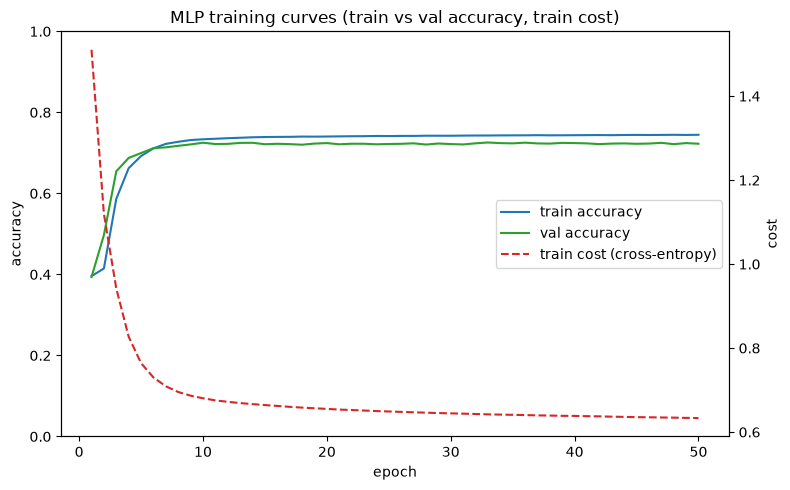

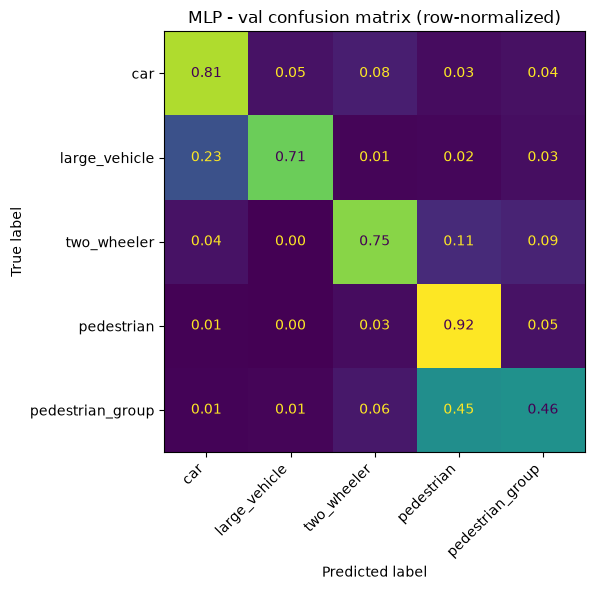

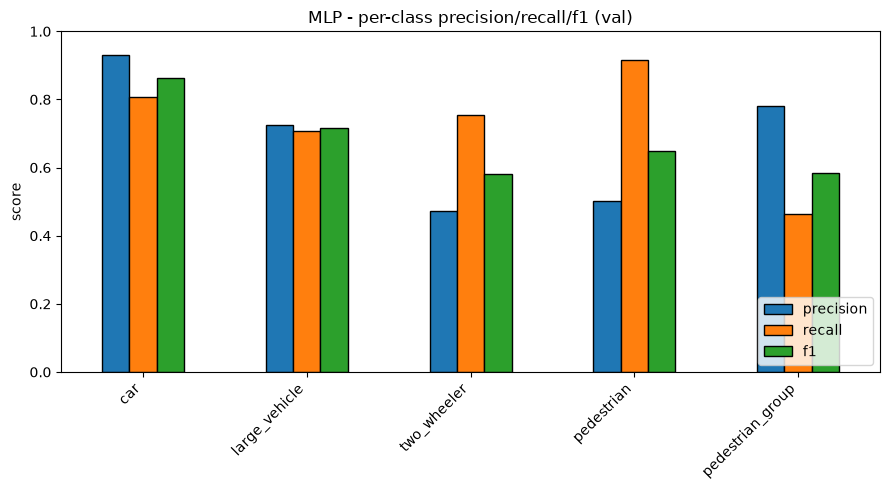

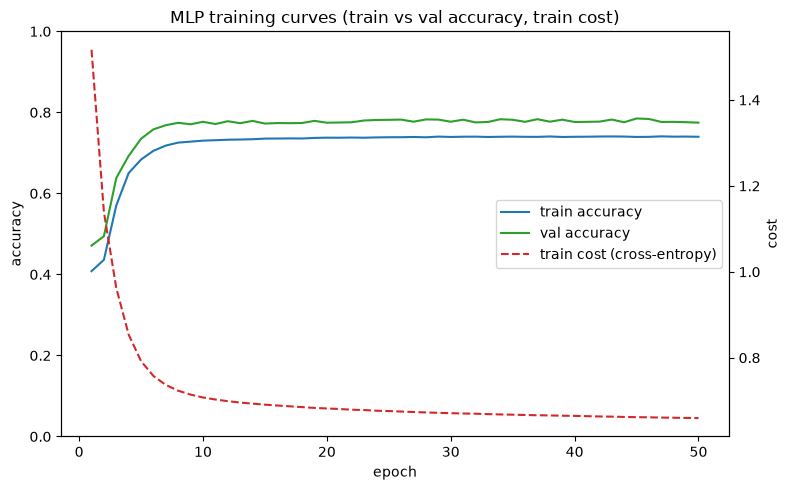

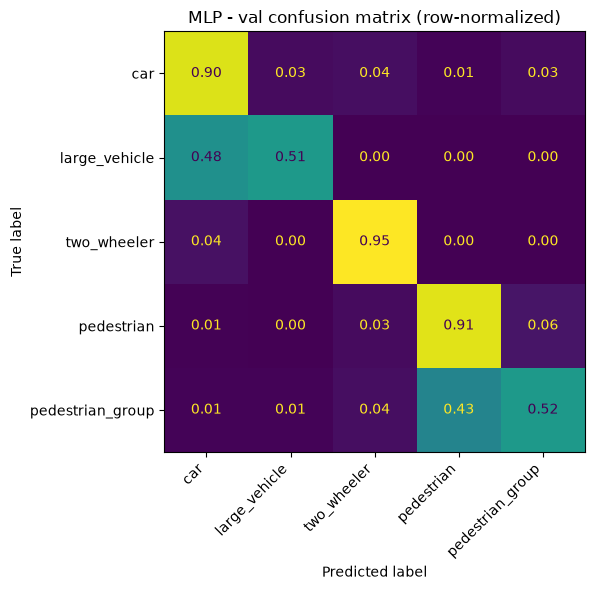

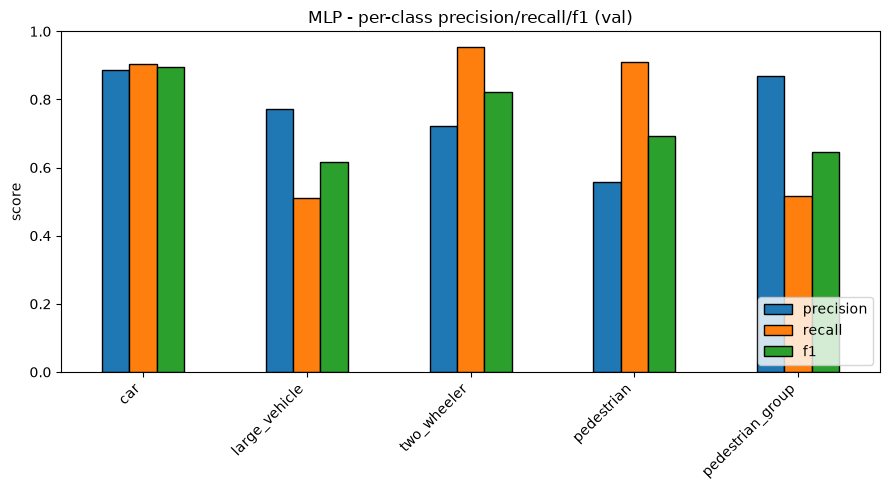

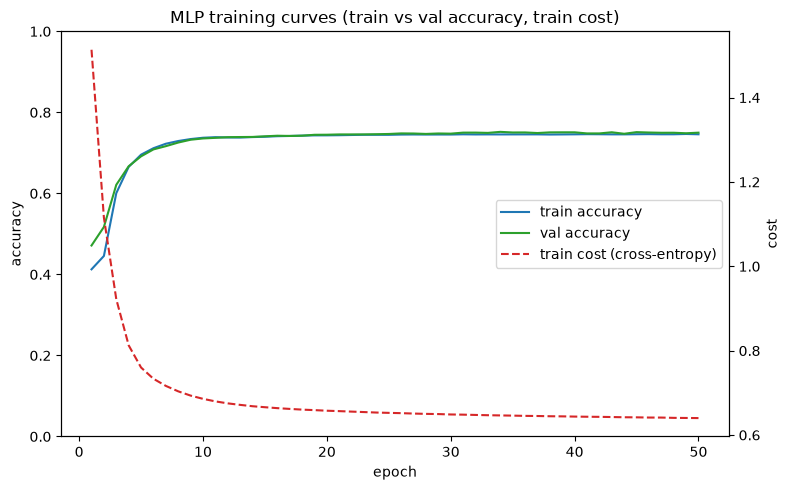

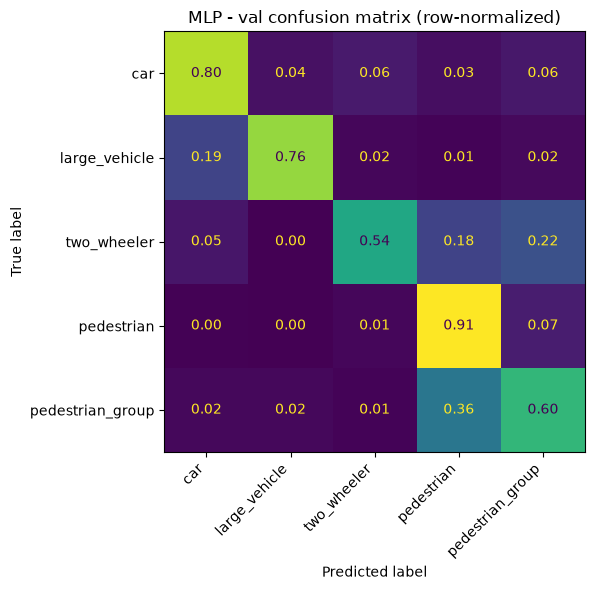

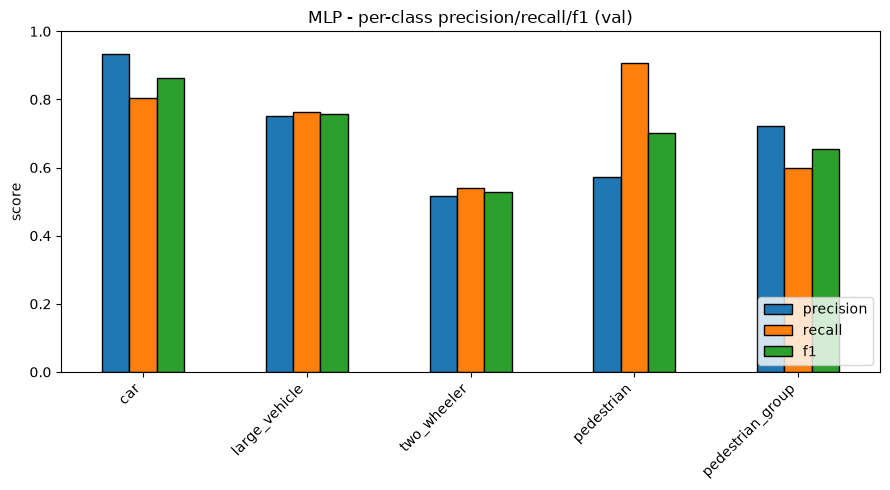

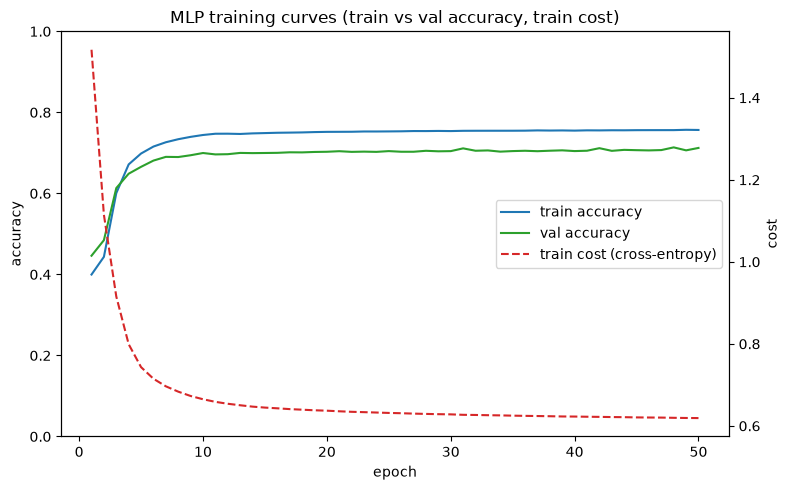

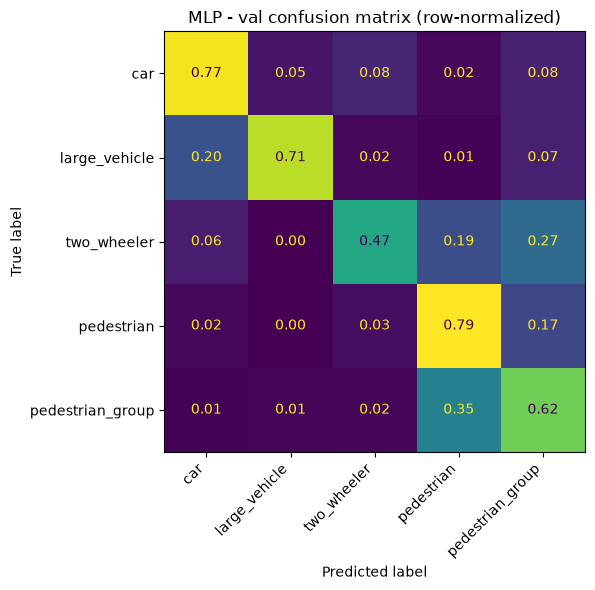

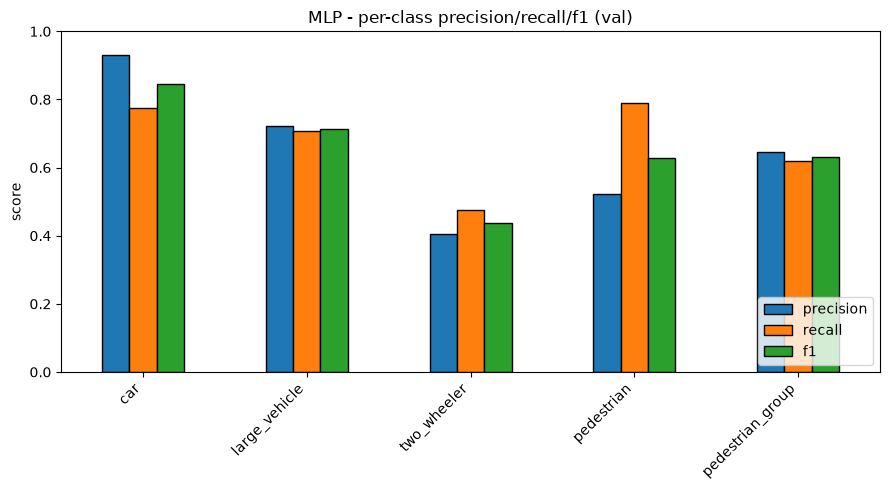

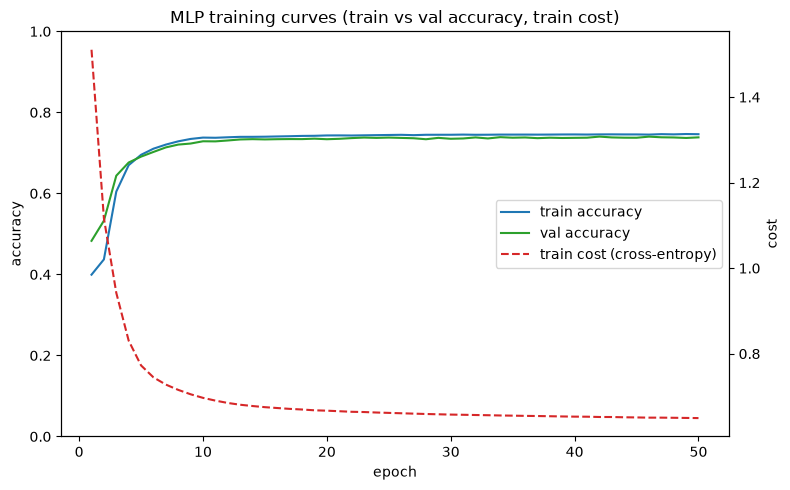

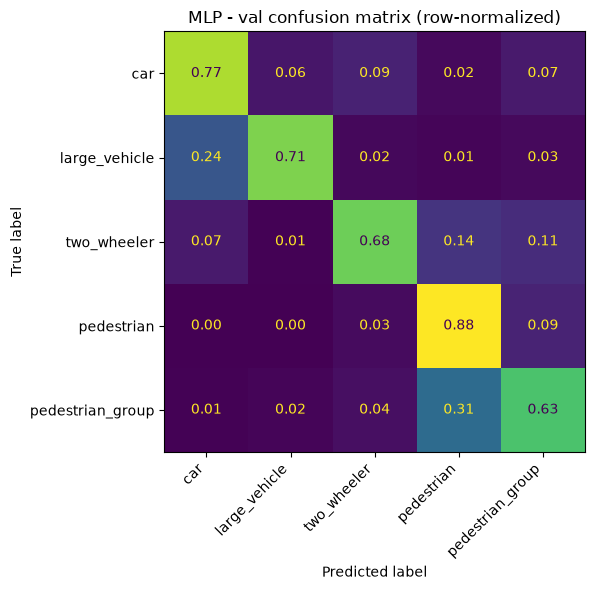

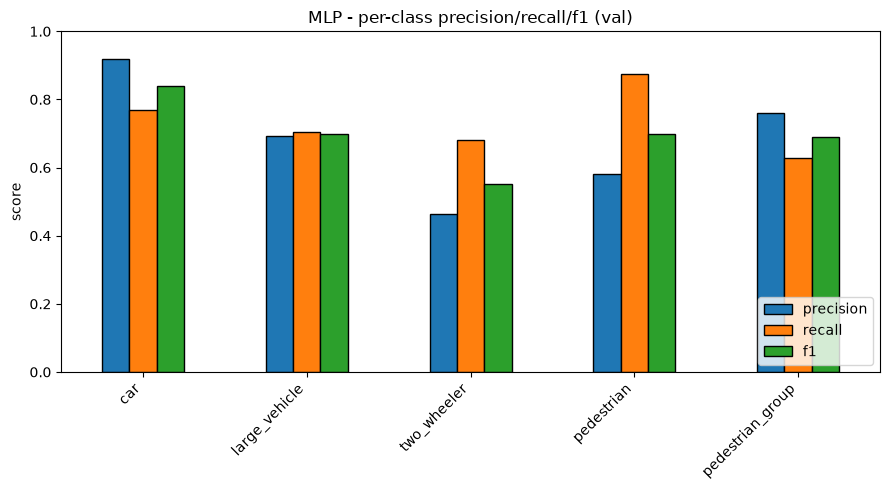

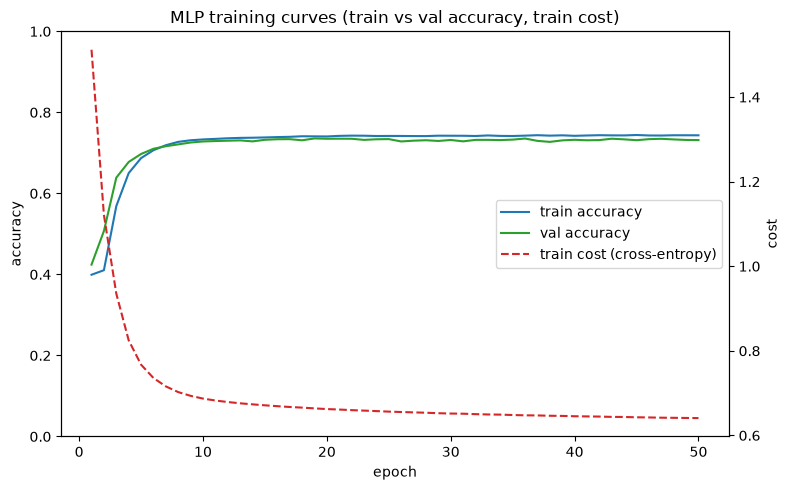

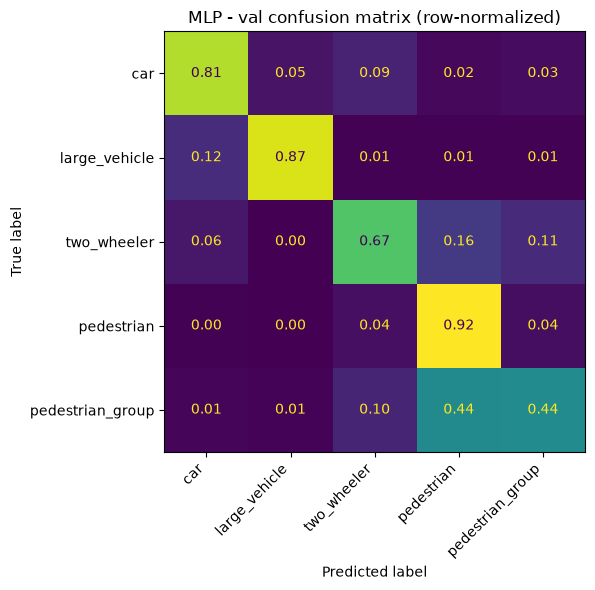

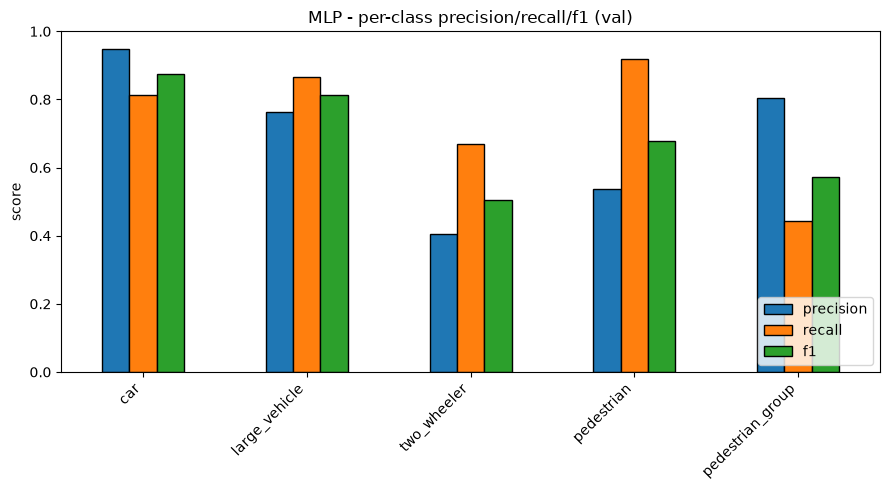

In [7]:
# cached - reruns the KS scoring (cheap) and loads each fold's cached model, no retraining
split_summary = run_split_sensitivity(df)
split_summary

Macro F1 ranged 0.651 to 0.734 across the 6 splits, purely from which sequences landed in val, wider than the `range_sc` gap (0.018). The best-matching train/val distribution split actually scored near the worst, so distribution match doesn't predict performance either.

**Decision:** keep the standing split, no candidate is a demonstrated improvement. The `range_sc` vs `baseline` comparison is closed as noise.

Root cause, briefly: a sequence-grouped split can't guarantee a class's radar signature is well mixed between train/val when concentrated in a handful of sequences, e.g. a bicycle stopped at a light (near-zero Doppler, narrow RCS) vs one crossing broadside (near-zero Doppler, much larger RCS), same label, different feature distribution. Full writeup: `MLP_Decisions_and_Findings.md`, Summary.

## Architecture capacity: hidden_dim ablation

Is the 16-unit hidden layer actually a bottleneck, or does the histogram feature representation cap performance regardless of model size? Same architecture shape (2 hidden layers), same features/taxonomy/batch size/LR/epochs as `baseline`, only `hidden_dim` changes: 8, 32, 64, against the standing 16. Defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.786  0.857    31055
large_vehicle         0.705   0.797  0.748     6247
two_wheeler           0.485   0.537  0.509     4629
pedestrian            0.553   0.877  0.679    11325
pedestrian_group      0.709   0.597  0.648    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png


...

Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden32/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.786  0.856    31055
large_vehicle         0.681   0.805  0.738     6247
two_wheeler           0.469   0.561  0.511     4629
pedestrian            0.558   0.853  0.674    11325
pedestrian_group      0.725   0.603  0.659    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_precision_recall_f1.png


,variant,hidden_dim,macro_f1
0,hidden8,8,0.688272
1,baseline,16,0.686342
2,hidden32,32,0.687698
3,hidden64,64,0.687536


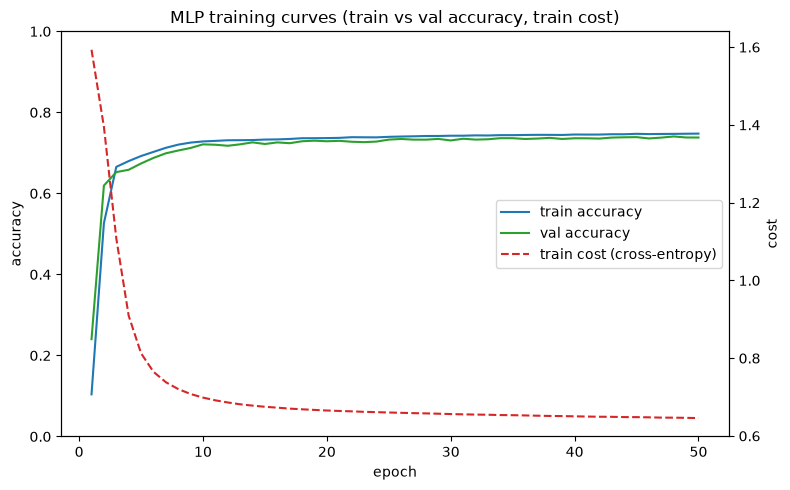

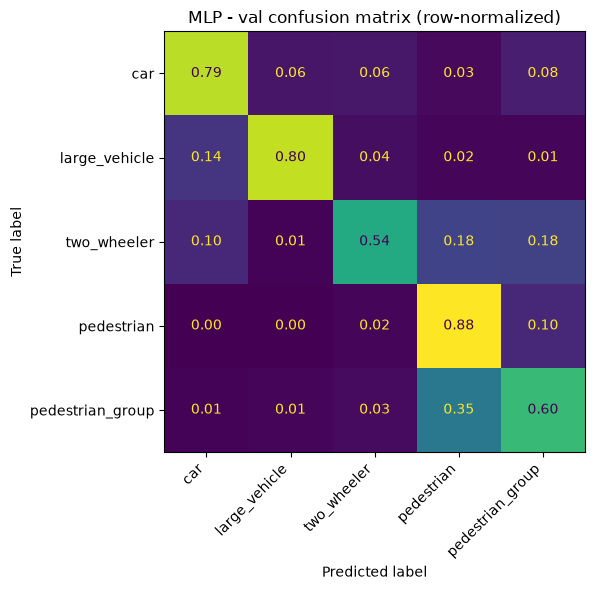

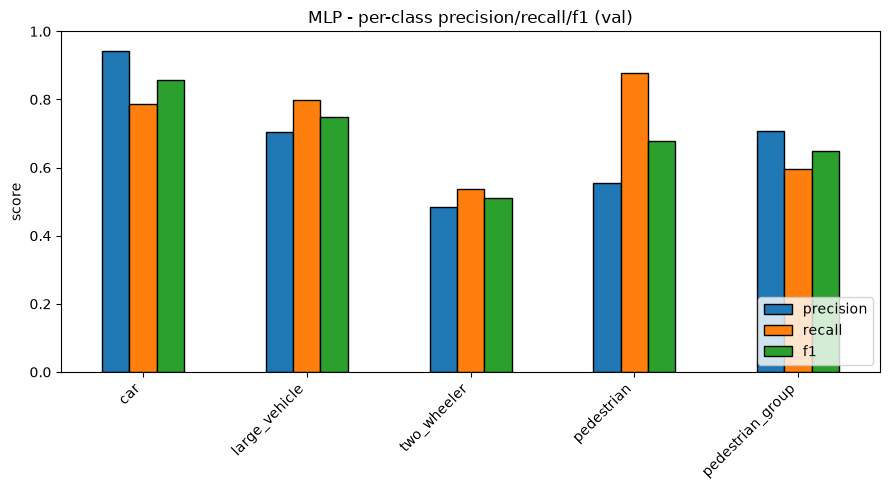

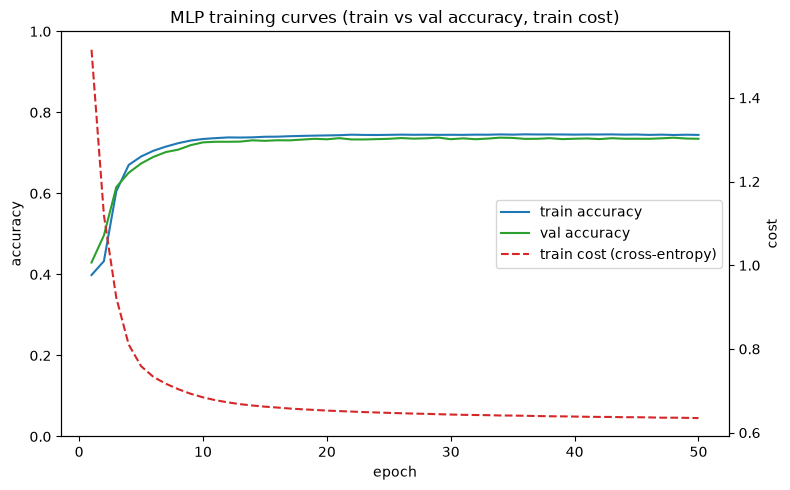

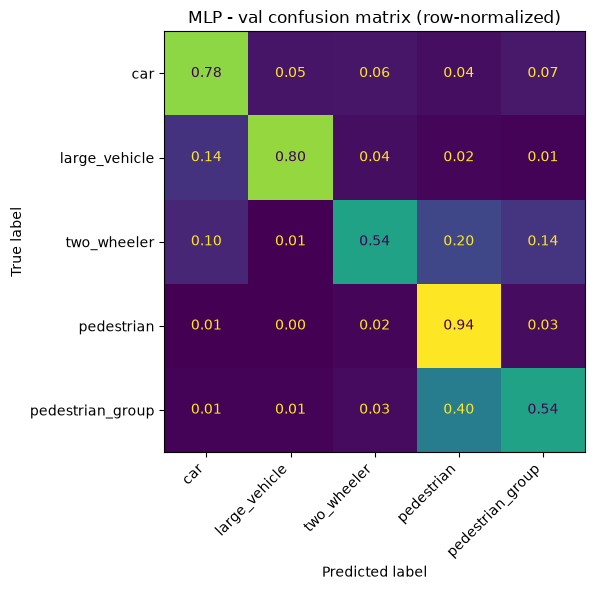

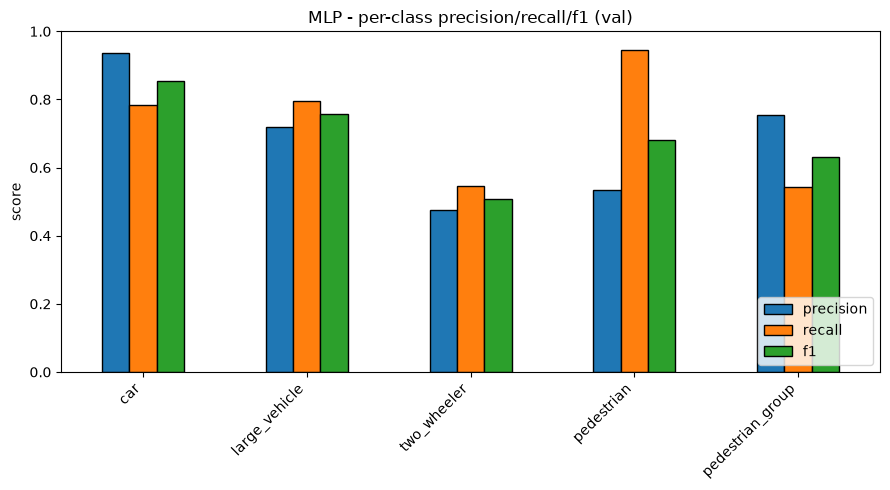

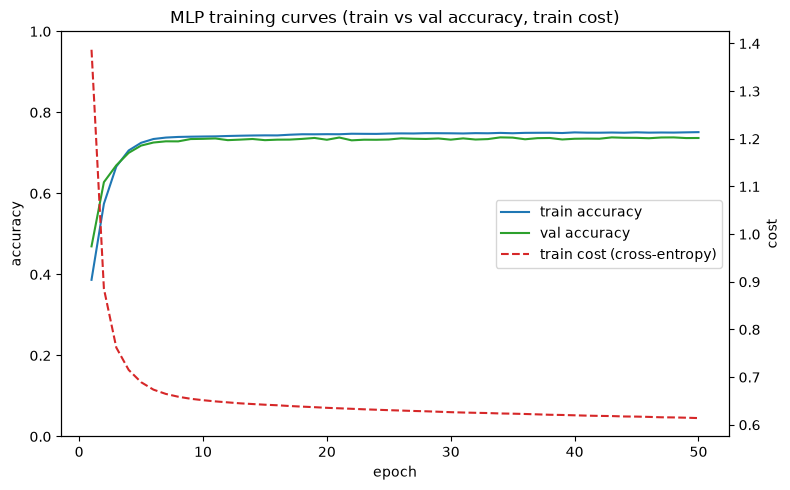

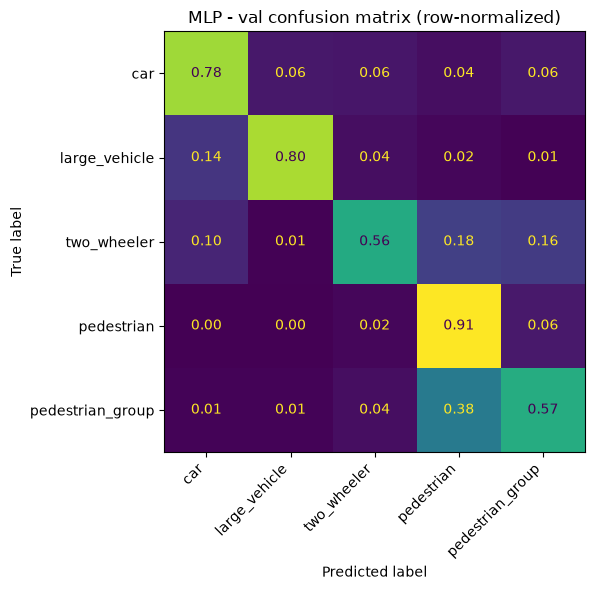

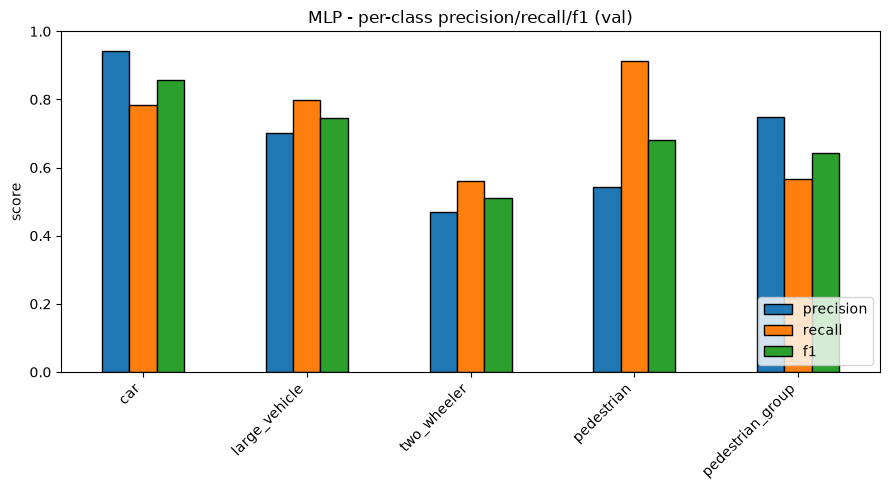

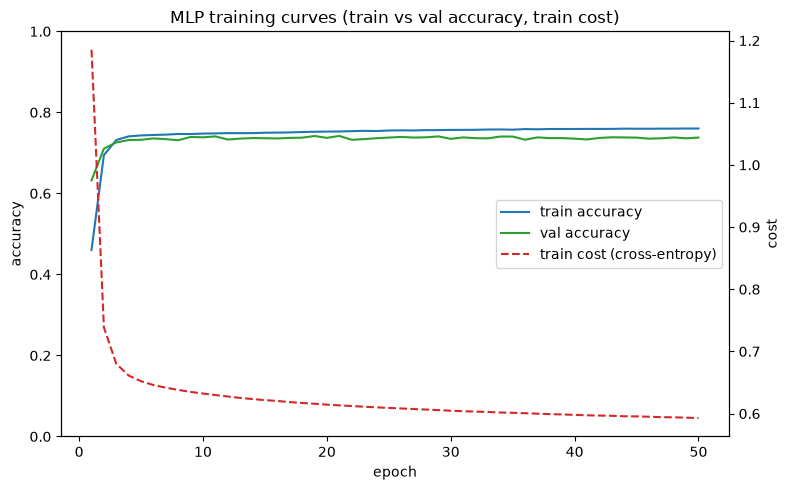

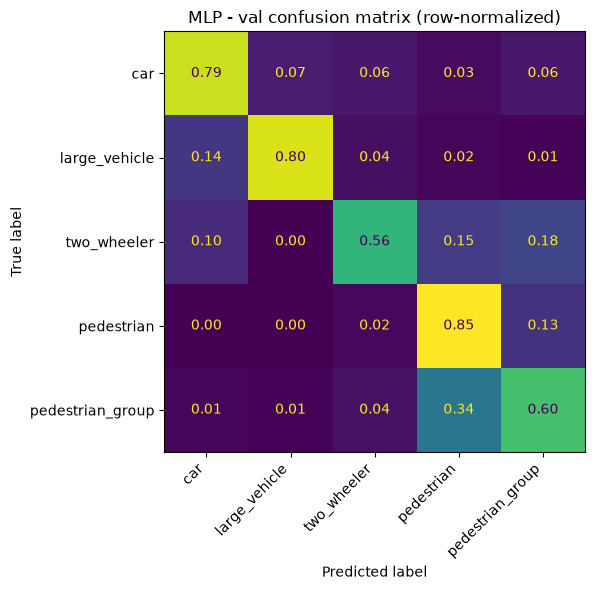

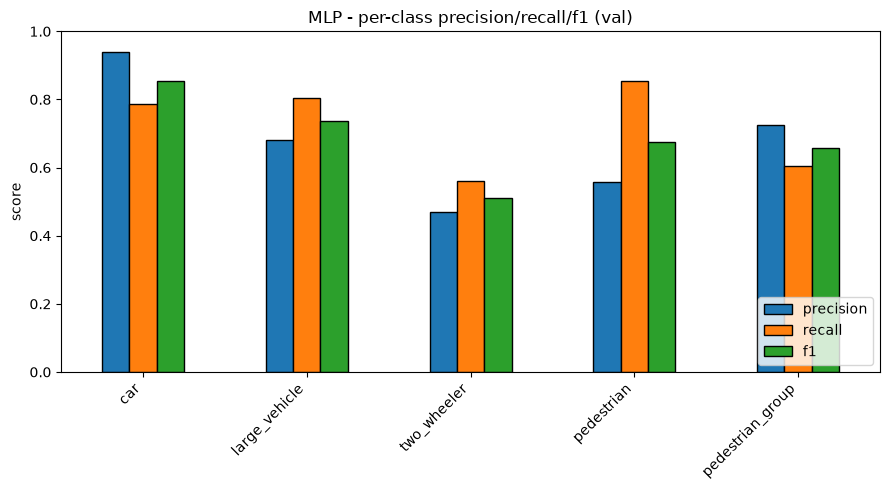

In [8]:
# all cached, no retraining
hidden_dims = {"hidden8": 8, "baseline": 16, "hidden32": 32, "hidden64": 64}
hidden_rows = []
for variant, dim in hidden_dims.items():
    _, _, m, _, _ = run_variant(df, variant)
    hidden_rows.append({"variant": variant, "hidden_dim": dim, "macro_f1": m["f1"].mean()})

import pandas as pd
pd.DataFrame(hidden_rows)

Macro F1: 0.688 (`hidden8`), 0.686 (`baseline`, 16), 0.688 (`hidden32`), 0.688 (`hidden64`), all within 0.002, far inside the noise floor (std 0.027). An 8x capacity range moves nothing.

**Finding:** the model isn't capacity-limited, the histogram representation is the ceiling, not the network's expressive power.

**Decision:** retain `HIDDEN_DIM=16`. Full writeup: `MLP_Decisions_and_Findings.md` section 6.

### Per-class check: is capacity hiding behind the macro average?

Macro F1 could be flat while individual classes trade off against each other. Checked directly, and cross-checked against the per-class spread already measured from split choice alone (the split sensitivity table above), since that's the real noise floor to judge against, not intuition.

/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.786  0.857    31055
large_vehicle         0.705   0.797  0.748     6247
two_wheeler           0.485   0.537  0.509     4629
pedestrian            0.553   0.877  0.679    11325
pedestrian_group      0.709   0.597  0.648    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden8/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png


...

Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden32/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.786  0.856    31055
large_vehicle         0.681   0.805  0.738     6247
two_wheeler           0.469   0.561  0.511     4629
pedestrian            0.558   0.853  0.674    11325
pedestrian_group      0.725   0.603  0.659    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/hidden64/mlp_precision_recall_f1.png


,hidden_dim spread (8-64),"split-choice spread (6 folds, noise reference)"
car,0.003156,0.055956
large_vehicle,0.018220,0.196742
two_wheeler,0.004527,0.385549
pedestrian,0.007586,0.073356
pedestrian_group,0.026466,0.116629


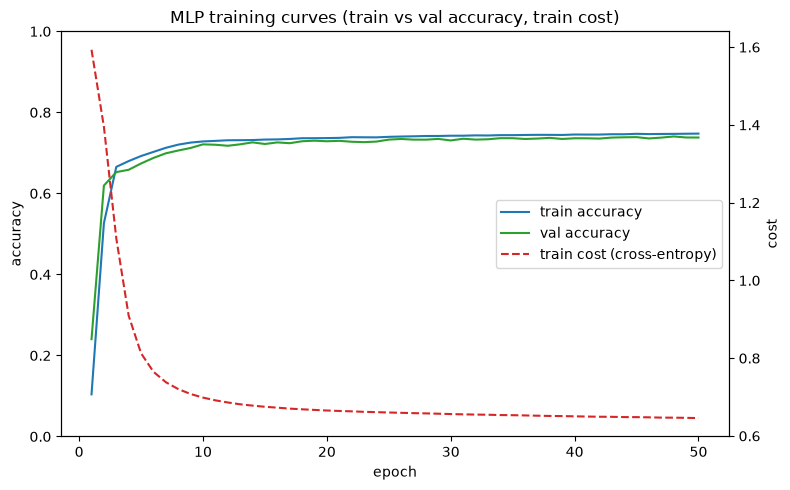

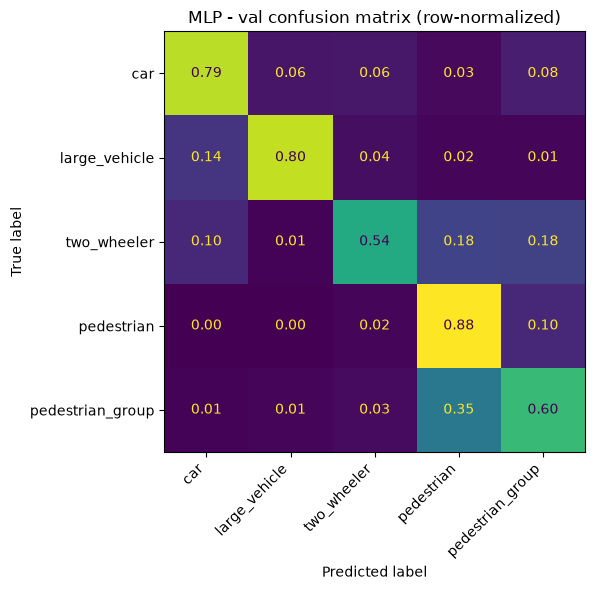

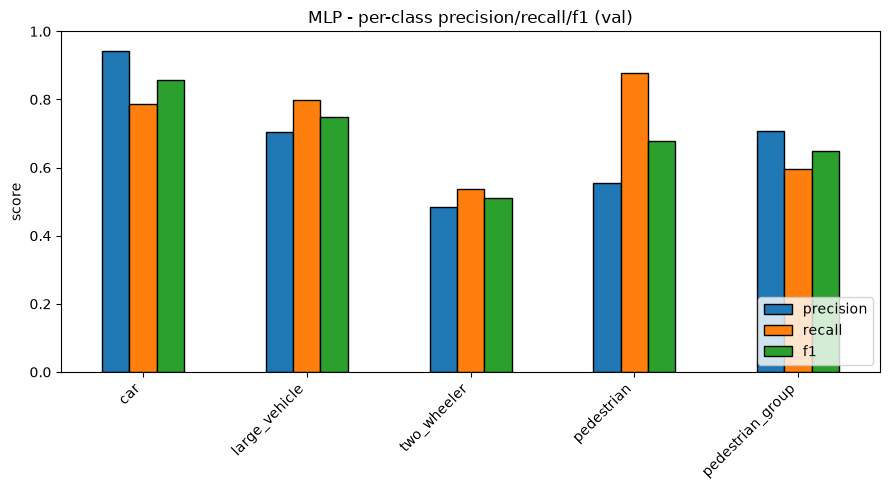

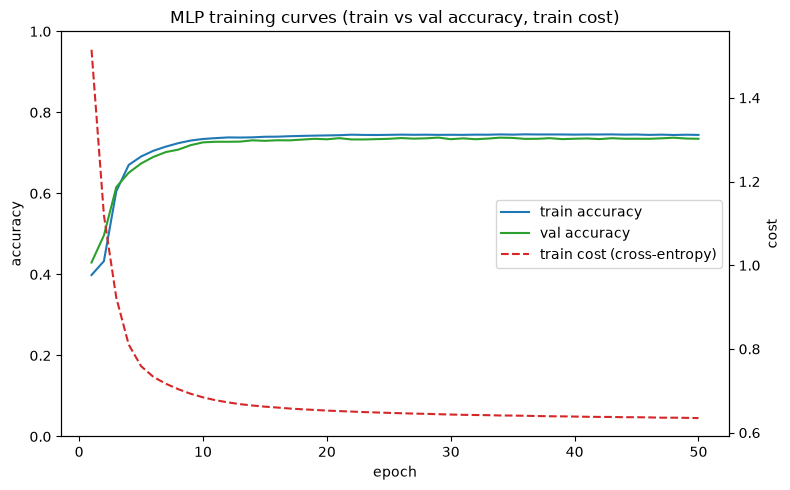

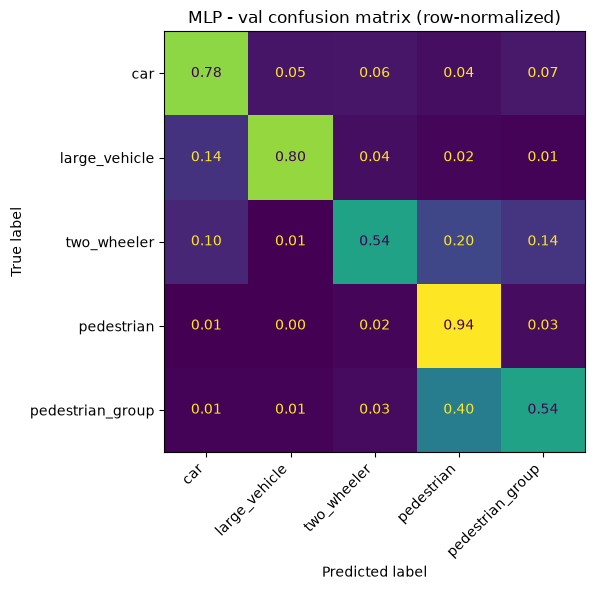

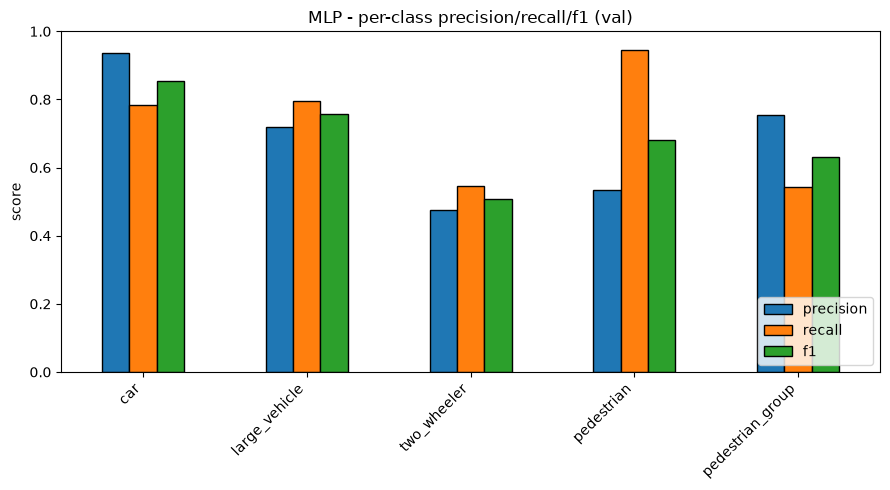

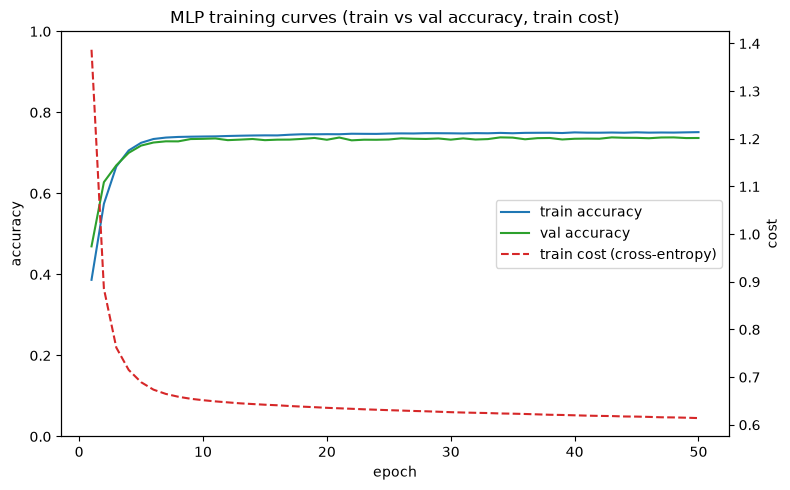

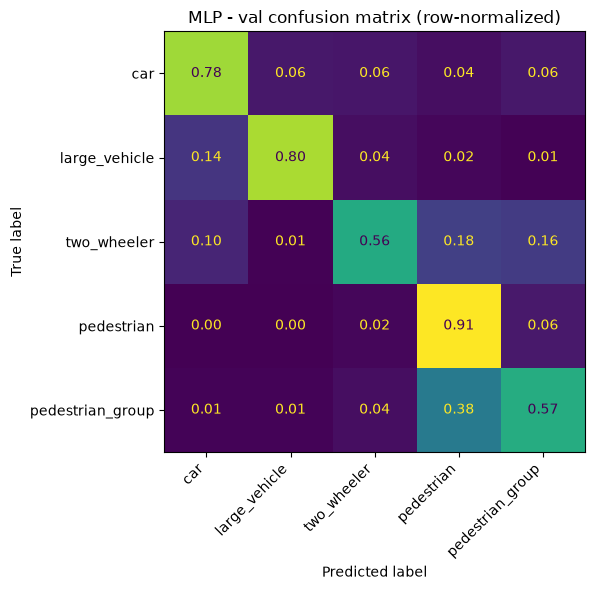

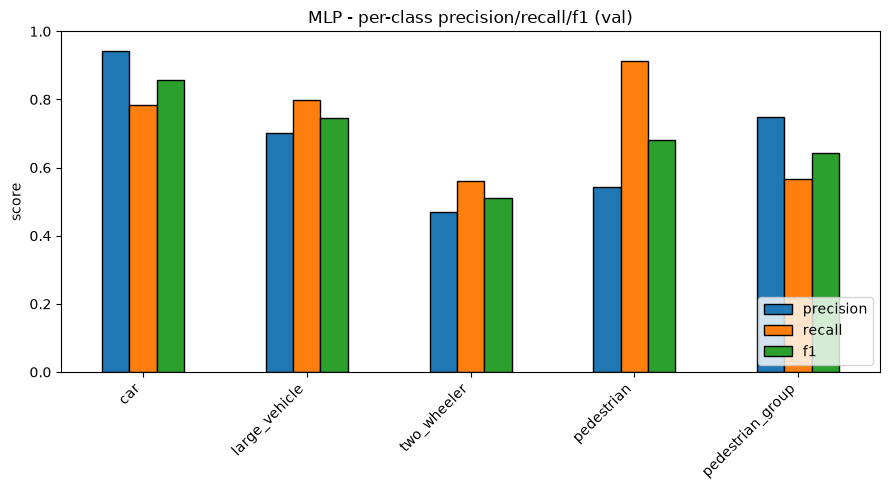

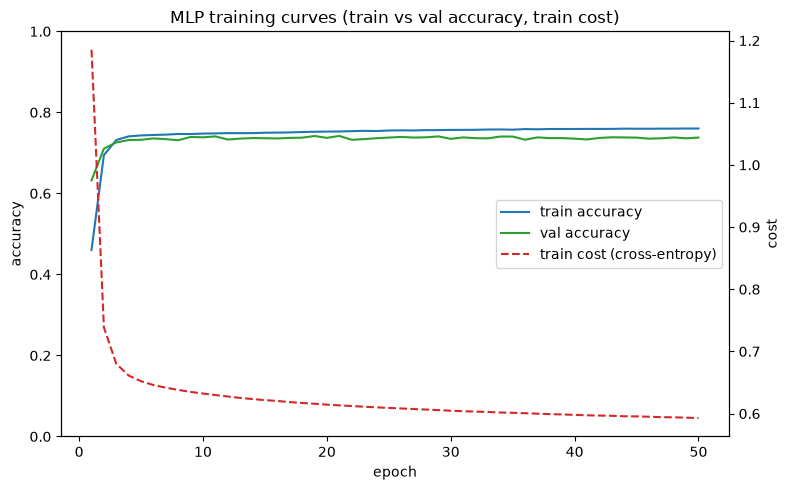

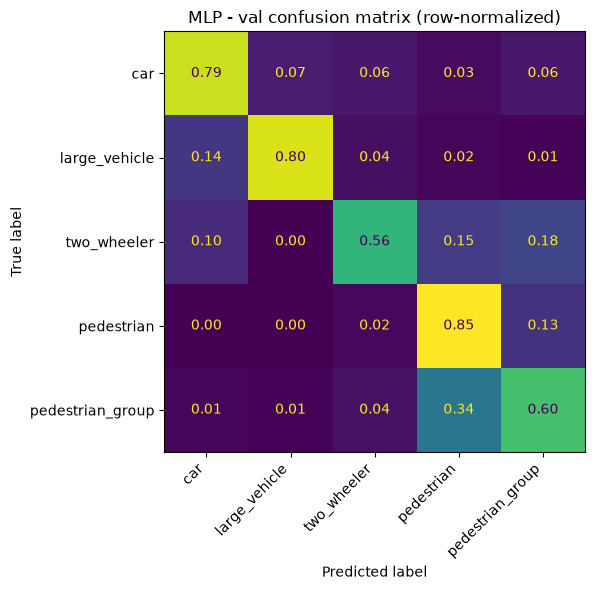

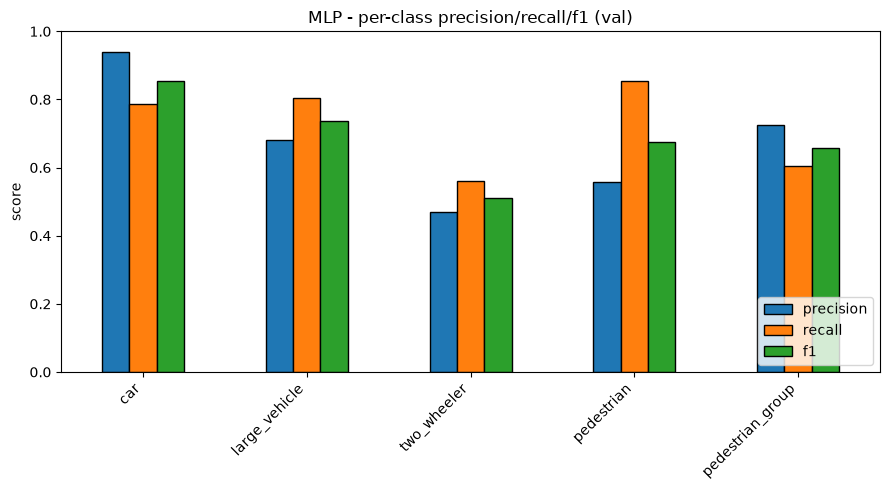

In [9]:
import json
from mlp_classifier import MLP_DIR

# cached, no retraining - per-class F1 by hidden_dim
hidden_per_class = {}
for variant in ["hidden8", "baseline", "hidden32", "hidden64"]:
    _, _, m, _, _ = run_variant(df, variant)
    hidden_per_class[variant] = m["f1"]
hidden_class_df = pd.DataFrame(hidden_per_class).T
hidden_spread = hidden_class_df.max() - hidden_class_df.min()

# cached val_metrics.json for each split-sensitivity fold - the noise reference
split_per_class = {}
for i in range(6):
    d = json.loads((MLP_DIR / "split_search" / f"fold_{i}" / "mlp_val_metrics.json").read_text())
    split_per_class[f"fold_{i}"] = {c: d[c]["f1"] for c in baseline_metrics.index}
split_class_df = pd.DataFrame(split_per_class).T
split_spread = split_class_df.max() - split_class_df.min()

pd.DataFrame({"hidden_dim spread (8-64)": hidden_spread, "split-choice spread (6 folds, noise reference)": split_spread})

No, not even per class. `pedestrian_group`'s hidden_dim spread (0.026) is the largest of any class, but that's still smaller than its own split-choice spread (0.117), and every other class shows the same pattern: whatever hidden_dim does to a class's F1 is dwarfed by what mere split choice already does to that same class. `two_wheeler` makes this starkest, spread of 0.005 from capacity against 0.386 from split choice alone. No class benefits from more or less capacity, the macro average wasn't hiding anything.

## Architecture depth: deep10 ablation (10 hidden layers)

Does going deeper help where going wider (previous section) didn't? Same features/taxonomy/N_BINS=16 as `baseline`, only depth varies: `n_hidden_layers=10` instead of 2, same `hidden_dim=16`. Defined in `scripts/mlp_variants.py`'s `deep10`.

First attempt (dropout=0.3, no batch normalization, lr=1e-5) collapsed to predicting only the majority class (`car`) for every point, macro F1 0.122 - a vanishing-gradient failure from stacking 10 unnormalized layers, not a real depth result. Not re-run here; full story in `MLP_Decisions_and_Findings.md` section 7. Fixed by adding batch normalization after each hidden layer, easing dropout to 0.1, and raising the learning rate to 1e-3.

/home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.936   0.824  0.877    31055
large_vehicle         0.889   0.768  0.824     6247
two_wheeler           0.542   0.482  0.510     4629
pedestrian            0.541   0.940  0.687    11325
pedestrian_group      0.719   0.586  0.646    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/deep10/mlp_precision_recall_f1.png


,precision,recall,f1,support
car,0.935777,0.824376,0.876551,31055
large_vehicle,0.889445,0.767568,0.824025,6247
two_wheeler,0.542072,0.481529,0.510010,4629
pedestrian,0.540994,0.940397,0.686853,11325
pedestrian_group,0.718954,0.586460,0.645983,17858


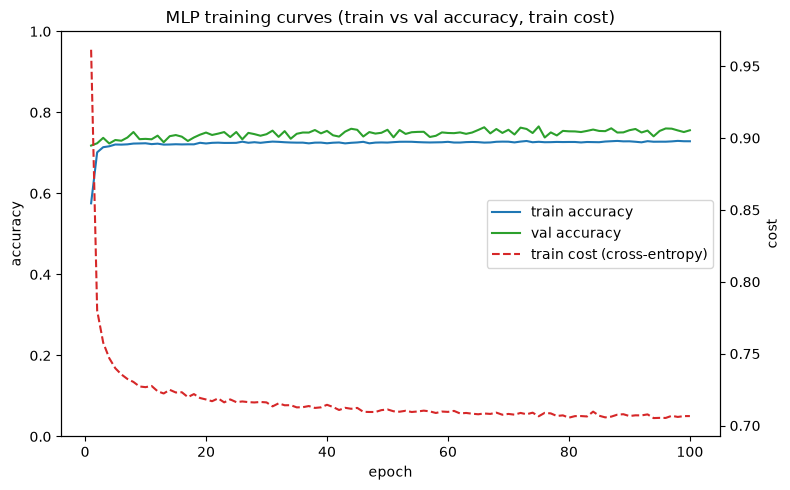

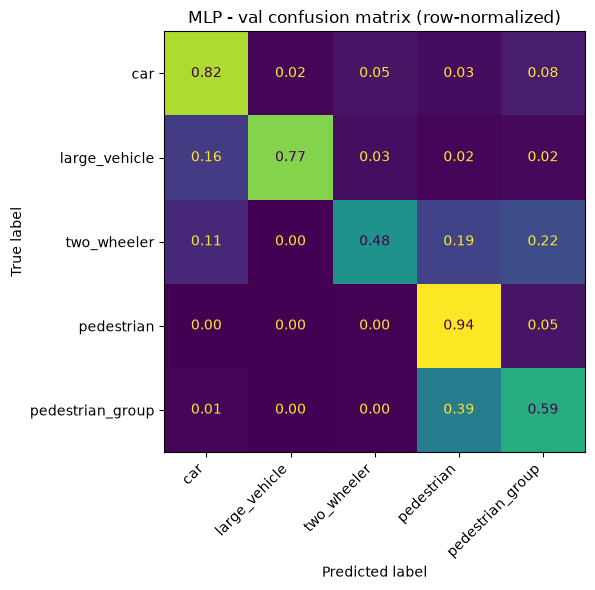

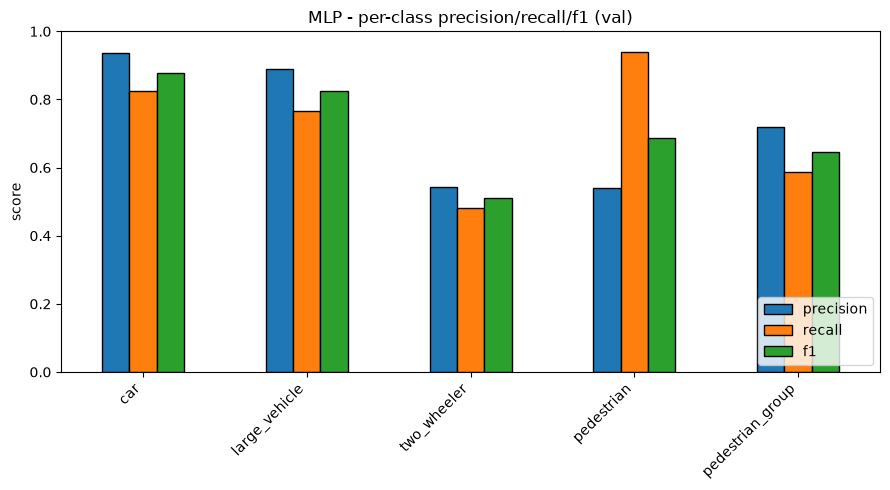

In [10]:
# cached, no retraining - the fixed (batch_norm + eased dropout + higher lr) config
_, _, deep10_metrics, _, _ = run_variant(df, "deep10")
deep10_metrics

In [11]:
# per-class delta vs baseline, checked against the same split-choice noise reference used for the hidden_dim sweep
delta = deep10_metrics["f1"] - baseline_metrics["f1"]
pd.DataFrame({
    "baseline_f1": baseline_metrics["f1"],
    "deep10_f1": deep10_metrics["f1"],
    "delta": delta,
    "split-choice spread (noise reference)": split_spread,
})

,baseline_f1,deep10_f1,delta,split-choice spread (noise reference)
car,0.853802,0.876551,0.022750,0.055956
large_vehicle,0.756059,0.824025,0.067966,0.196742
two_wheeler,0.507601,0.510010,0.002409,0.385549
pedestrian,0.681956,0.686853,0.004897,0.073356
pedestrian_group,0.632295,0.645983,0.013688,0.116629


Macro F1: 0.709 (`deep10`) vs 0.686 (`baseline`), +0.023. Looks like a gain, but every per-class delta sits inside that class's split-choice noise spread, including `two_wheeler` (+0.002 vs spread 0.386), the class actually driving the macro F1 ceiling.

**Finding:** not a real improvement. Depth doesn't help once trainable, same conclusion as the width sweep.

**Decision:** retain the 2-hidden-layer baseline.

Also surfaced a real caching bug: `evaluate_val_metrics` reused a stale `mlp_val_metrics.json` from the collapsed first attempt after retraining in place, since it only checked file existence, not whether it matched the current model. Fixed by invalidating the cache whenever older than the model file. Full writeup: `MLP_Decisions_and_Findings.md` section 7.

## Feature design: point count

Histogram features are fraction-of-points-per-bin, discarding instance point count entirely. Two ways to put it back: `n_points` (baseline plus one extra scalar, raw point count appended unbinned) and `raw_counts` (baseline with unnormalized per-bin counts instead of fractions, `normalize=false`). Defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.938   0.788  0.856    31055
large_vehicle         0.745   0.797  0.770     6247
two_wheeler           0.480   0.553  0.514     4629
pedestrian            0.553   0.861  0.674    11325
pedestrian_group      0.698   0.602  0.646    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/n_points/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.936   0.786  0.855    31055
large_vehicle         0.721   0.796  0.757     6247
two_wheeler           0.489   0.544  0.515     4629
pedestrian            0.546   0.908  0.682    11325
pedestrian_group      0.728   0.576  0.643    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/raw_counts/mlp_precision_recall_f1.png


,baseline,n_points,raw_counts
car,0.853802,0.856123,0.854698
large_vehicle,0.756059,0.770195,0.756675
two_wheeler,0.507601,0.514062,0.514730
pedestrian,0.681956,0.673875,0.681776
pedestrian_group,0.632295,0.646364,0.642908


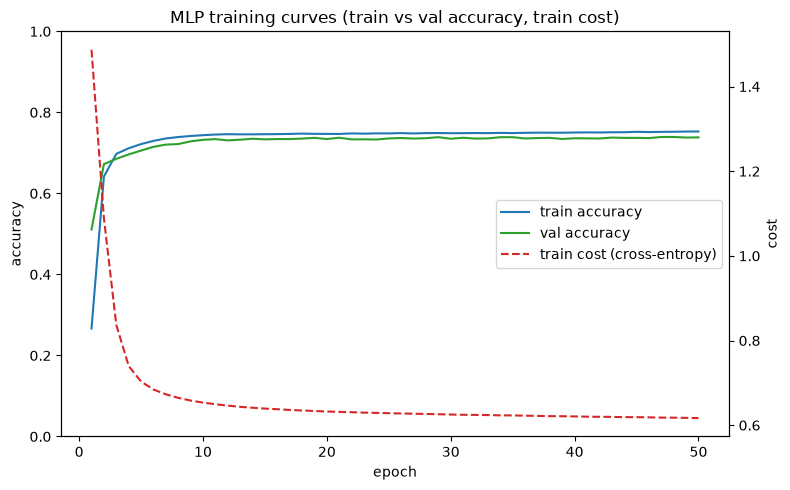

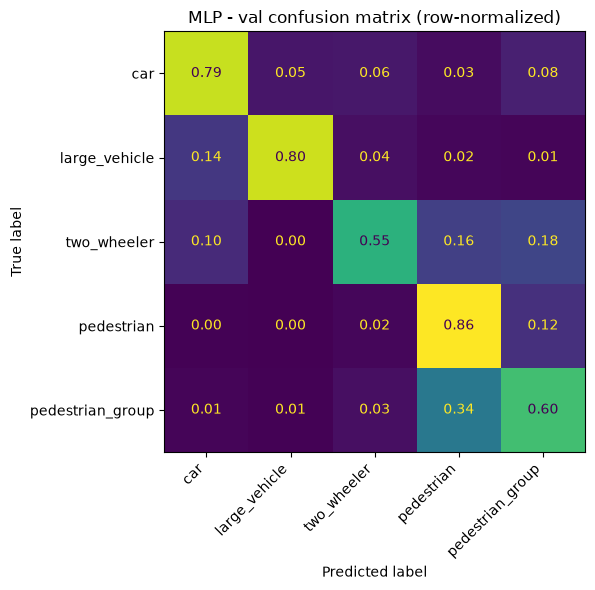

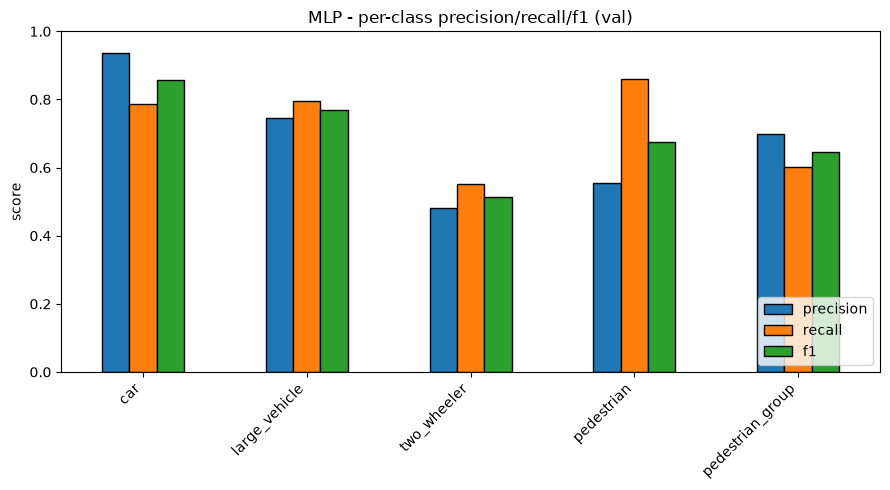

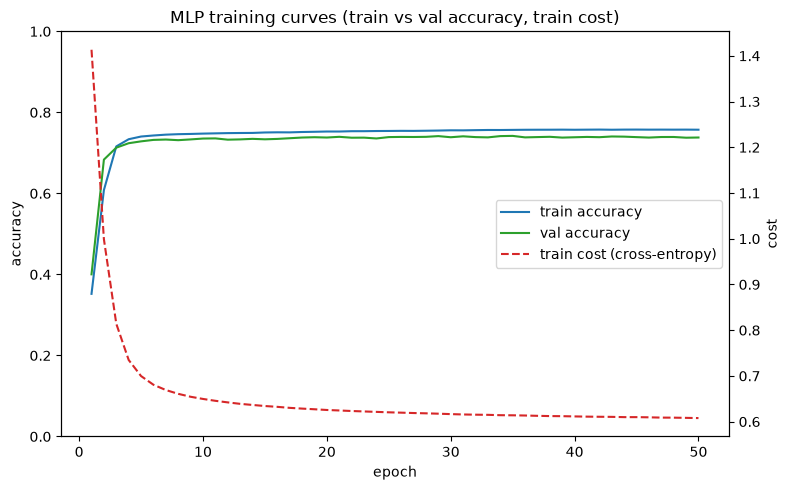

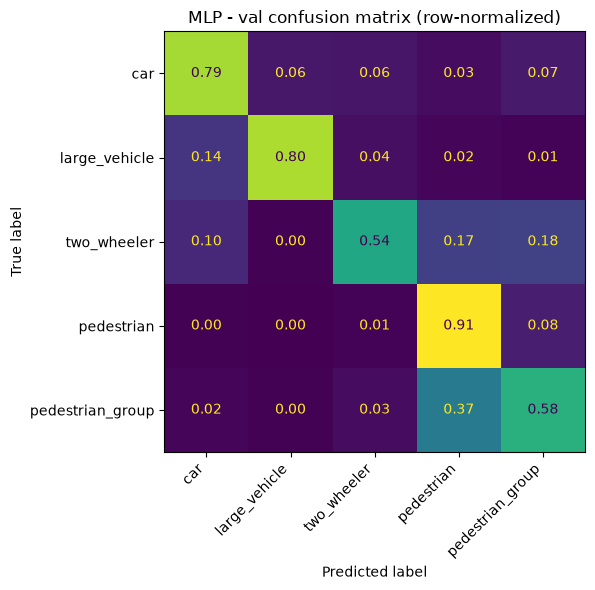

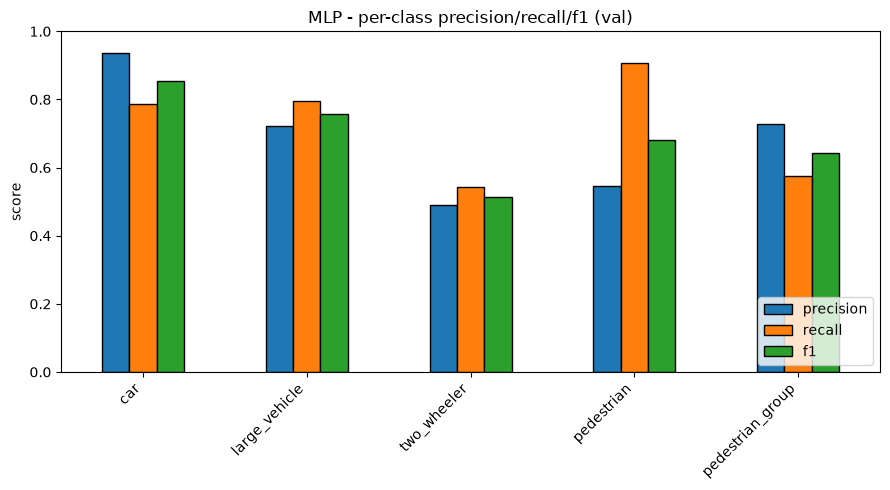

In [12]:
# both cached, no retraining
_, _, n_points_metrics, _, _ = run_variant(df, "n_points")
_, _, raw_counts_metrics, _, _ = run_variant(df, "raw_counts")
pd.DataFrame({
    "baseline": baseline_metrics["f1"],
    "n_points": n_points_metrics["f1"],
    "raw_counts": raw_counts_metrics["f1"],
})

Macro F1: `baseline` 0.686, `n_points` 0.692, `raw_counts` 0.690, both inside the noise floor per-class too. Both nudge the `pedestrian`/`pedestrian_group` precision/recall balance the theoretically expected way, but neither shift clears noise.

**Finding:** not a real improvement, by either route, two independent mechanisms for handing the network point count converge on the same null result. Full writeup: `MLP_Decisions_and_Findings.md` section 8.

## Feature design: orientation and angular features

`x_rel`/`y_rel` are per-point and orientation-dependent (a car seen broadside vs head-on spreads very differently across the two axes for the same physical object). Two tests: `spatial_extent` drops them for one orientation-robust scalar per instance (bounding-box diagonal); `azimuth_extent` adds a new scalar on top of `baseline` instead (angular spread as seen by the sensor, max-min of `azimuth_sc`, a point-level column nothing had used until now). Defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.782  0.855    31055
large_vehicle         0.715   0.801  0.756     6247
two_wheeler           0.465   0.553  0.505     4629
pedestrian            0.545   0.928  0.687    11325
pedestrian_group      0.751   0.570  0.648    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.941   0.790  0.859    31055
large_vehicle         0.723   0.799  0.759     6247
two_wheeler           0.496   0.571  0.531     4629
pedestrian            0.542   0.932  0.685    11325
pedestrian_group      0.756   0.565  0.647    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/azimuth_extent/mlp_precision_recall_f1.png


,baseline,spatial_extent,azimuth_extent
car,0.853802,0.854865,0.859018
large_vehicle,0.756059,0.755643,0.758935
two_wheeler,0.507601,0.505031,0.531124
pedestrian,0.681956,0.687188,0.685484
pedestrian_group,0.632295,0.647947,0.646814


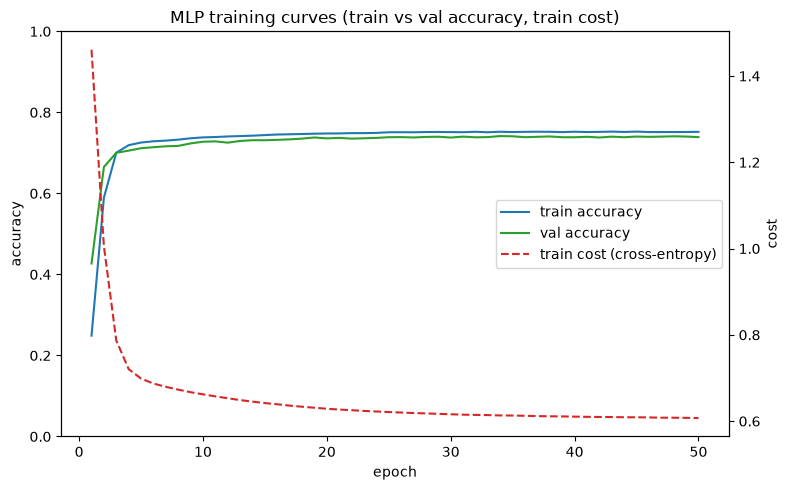

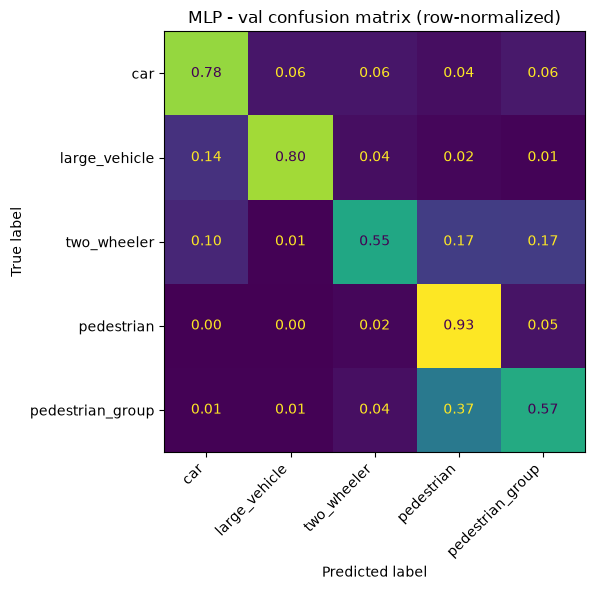

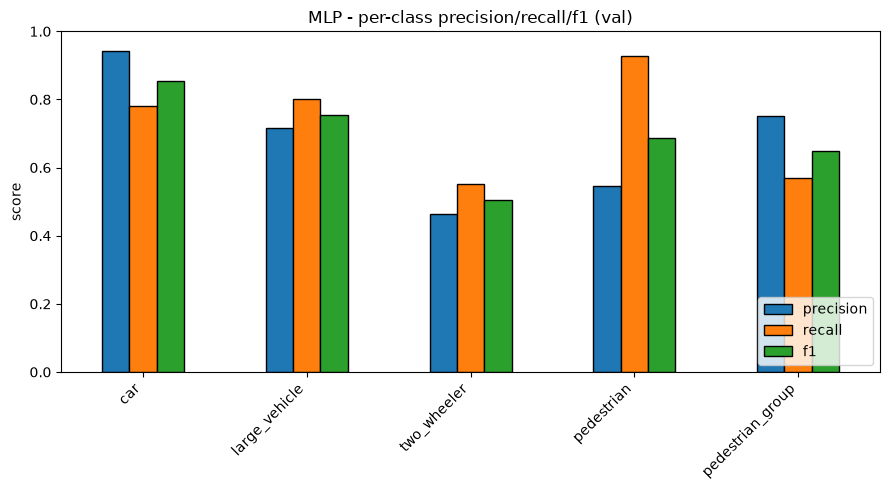

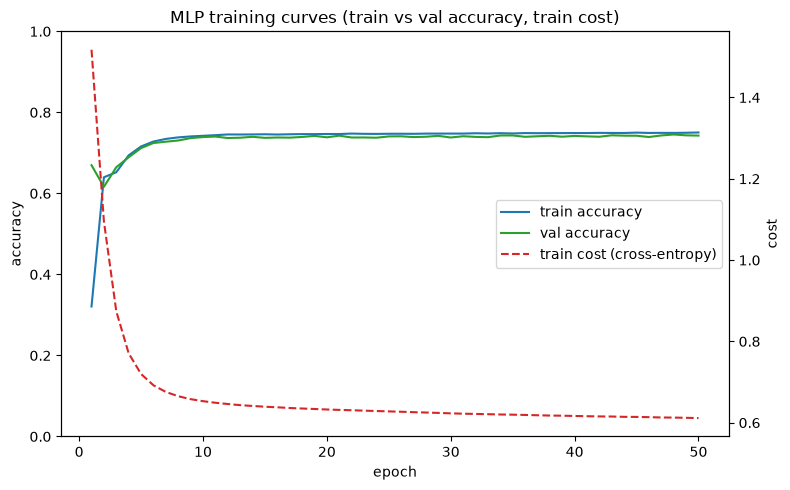

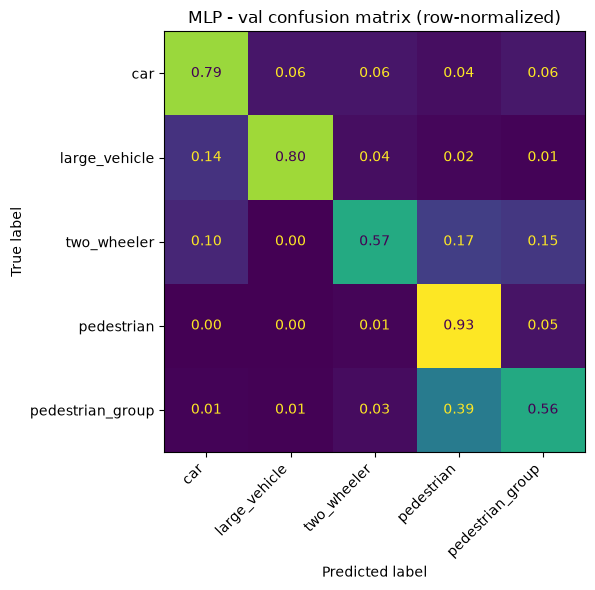

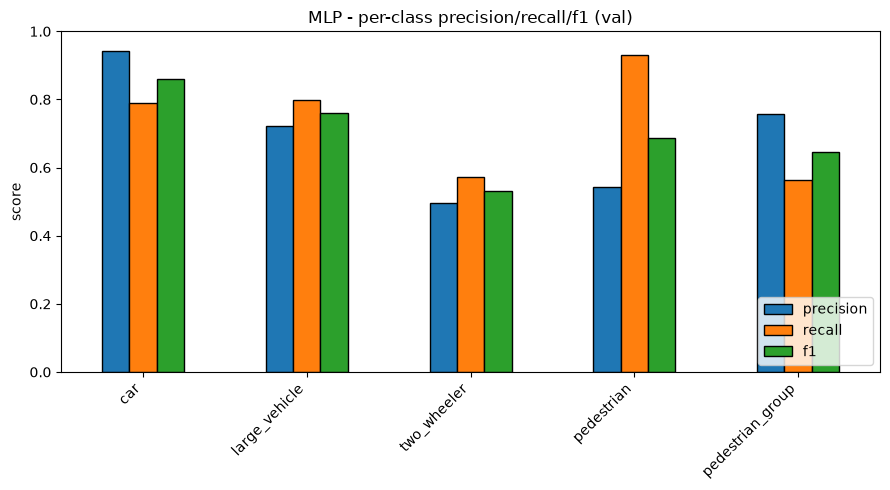

In [13]:
# both cached, no retraining
_, _, spatial_extent_metrics, _, _ = run_variant(df, "spatial_extent")
_, _, azimuth_extent_metrics, _, _ = run_variant(df, "azimuth_extent")
pd.DataFrame({
    "baseline": baseline_metrics["f1"],
    "spatial_extent": spatial_extent_metrics["f1"],
    "azimuth_extent": azimuth_extent_metrics["f1"],
})

Macro F1: `baseline` 0.686, `spatial_extent` 0.690, `azimuth_extent` 0.696. Every per-class delta sits inside the split-choice noise floor; `azimuth_extent`'s `two_wheeler` delta (+0.023) is the largest of any feature-design test so far, still a fraction of that class's 0.386 noise spread.

### Does spatial_extent narrow the noise floor itself?

`spatial_extent` was built to remove the orientation-sensitivity mechanism thought to drive part of the split-to-split noise (see Key takeaways in `MLP_Decisions_and_Findings.md`), so baseline's noise floor isn't automatically the right reference for it. Checked directly: reran the same 6-split sweep with `spatial_extent`'s feature set (`split_sensitivity.run_split_sensitivity`'s `features`/`extra_features`/`output_subdir` params), cached at `results/mlp/split_search_spatial_extent/fold_<n>/`, loaded here rather than rerun (~20min for 6 folds).

In [14]:
# loads cached fold results for both feature sets - no retraining
spatial_extent_split_per_class = {}
for i in range(6):
    d = json.loads((MLP_DIR / "split_search_spatial_extent" / f"fold_{i}" / "mlp_val_metrics.json").read_text())
    spatial_extent_split_per_class[f"fold_{i}"] = {c: d[c]["f1"] for c in baseline_metrics.index}
spatial_extent_split_class_df = pd.DataFrame(spatial_extent_split_per_class).T
spatial_extent_split_spread = spatial_extent_split_class_df.max() - spatial_extent_split_class_df.min()

pd.DataFrame({
    "baseline split-choice spread": split_spread,
    "spatial_extent split-choice spread": spatial_extent_split_spread,
})

,baseline split-choice spread,spatial_extent split-choice spread
car,0.055956,0.055087
large_vehicle,0.196742,0.167084
two_wheeler,0.385549,0.355660
pedestrian,0.073356,0.074278
pedestrian_group,0.116629,0.115436


Not meaningfully narrower. Macro F1 across the same 6 splits ranged 0.655-0.745 (std 0.030) vs baseline's 0.651-0.734 (std 0.027), essentially unchanged. `large_vehicle` and `two_wheeler`, the classes an orientation fix would most plausibly help, shrank a little (0.197->0.167, 0.386->0.356) but not enough to matter; `car`/`pedestrian`/`pedestrian_group` were flat.

**Finding:** sixth independent axis (capacity, depth, `n_points`, `raw_counts`, `spatial_extent`, `azimuth_extent`) landing inside the noise floor, both on the fixed baseline split and, for `spatial_extent`, across the noise floor itself. Reinforces that the ceiling isn't from any one specific feature-engineering choice, it's more fundamental to what this per-instance summary vector can express at ~2.9 points/instance average. Full writeup: `MLP_Decisions_and_Findings.md` section 9.

## Point count diagnostic: does sparsity explain the ceiling directly?

Sections above tested whether handing the network more information helps (six null results). This asks a more direct question: slice the *existing* `baseline` model's val predictions by instance point count, no retraining, and check whether error is actually concentrated in sparse instances. `mlp_classifier.evaluate_by_point_count`.

In [15]:
from mlp_classifier import evaluate_by_point_count

# no retraining - loads baseline's cached model, buckets its own val predictions
point_count_summary = evaluate_by_point_count(df)
point_count_summary

            n  accuracy  macro_f1  f1_car  f1_large_vehicle  f1_two_wheeler  f1_pedestrian  f1_pedestrian_group  support_car  support_large_vehicle  support_two_wheeler  support_pedestrian  support_pedestrian_group
bucket                                                                                                                                                                                                                
1       24004     0.619     0.381   0.839             0.037           0.389          0.641                0.000        10295                    656                 1391                6318                      5344
2       17353     0.741     0.606   0.856             0.237           0.516          0.747                0.673         8287                    467                 1281                3117                      4201
3       11711     0.800     0.702   0.881             0.471           0.597          0.770                0.791         5923                

,n,accuracy,macro_f1,f1_car,f1_large_vehicle,f1_two_wheeler,f1_pedestrian,f1_pedestrian_group,support_car,support_large_vehicle,support_two_wheeler,support_pedestrian,support_pedestrian_group
bucket,,,,,,,,,,,,,
1,24004,0.618772,0.381225,0.838965,0.037158,0.388626,0.641377,0.000000,10295,656,1391,6318,5344
2,17353,0.740564,0.605562,0.856412,0.236669,0.515607,0.746547,0.672573,8287,467,1281,3117,4201
3,11711,0.800102,0.702048,0.880937,0.470588,0.596899,0.770475,0.791339,5923,412,927,1277,3172
4,6567,0.820923,0.761536,0.877789,0.686911,0.651709,0.768328,0.822940,3156,399,497,447,2068
5,3507,0.814942,0.764024,0.847141,0.833163,0.658407,0.651613,0.829795,1427,452,287,117,1224
6-10,6348,0.854442,0.714946,0.797672,0.962798,0.525122,0.476190,0.812950,1679,2651,242,49,1727
11+,1624,0.929187,0.537638,0.822355,0.995445,0.210526,0.000000,0.659864,288,1210,4,0,122


In [16]:
from mlp_classifier import format_point_count_deltas, plot_point_count_curve

# each bucket's delta vs the n_points=1 bucket, in parentheses - easier to read than raw values alone
format_point_count_deltas(point_count_summary)

,n,support_car,support_large_vehicle,support_two_wheeler,support_pedestrian,support_pedestrian_group,accuracy,macro_f1,f1_car,f1_large_vehicle,f1_two_wheeler,f1_pedestrian,f1_pedestrian_group
bucket,,,,,,,,,,,,,
1,24004,10295,656,1391,6318,5344,0.619,0.381,0.839,0.037,0.389,0.641,0.000
2,17353,8287,467,1281,3117,4201,0.741 (+0.122),0.606 (+0.224),0.856 (+0.017),0.237 (+0.200),0.516 (+0.127),0.747 (+0.105),0.673 (+0.673)
3,11711,5923,412,927,1277,3172,0.800 (+0.181),0.702 (+0.321),0.881 (+0.042),0.471 (+0.433),0.597 (+0.208),0.770 (+0.129),0.791 (+0.791)
4,6567,3156,399,497,447,2068,0.821 (+0.202),0.762 (+0.380),0.878 (+0.039),0.687 (+0.650),0.652 (+0.263),0.768 (+0.127),0.823 (+0.823)
5,3507,1427,452,287,117,1224,0.815 (+0.196),0.764 (+0.383),0.847 (+0.008),0.833 (+0.796),0.658 (+0.270),0.652 (+0.010),0.830 (+0.830)
6-10,6348,1679,2651,242,49,1727,0.854 (+0.236),0.715 (+0.334),0.798 (-0.041),0.963 (+0.926),0.525 (+0.136),0.476 (-0.165),0.813 (+0.813)
11+,1624,288,1210,4,0,122,0.929 (+0.310),0.538 (+0.156),0.822 (-0.017),0.995 (+0.958),0.211 (-0.178),0.000 (-0.641),0.660 (+0.660)


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_point_count_curve.png


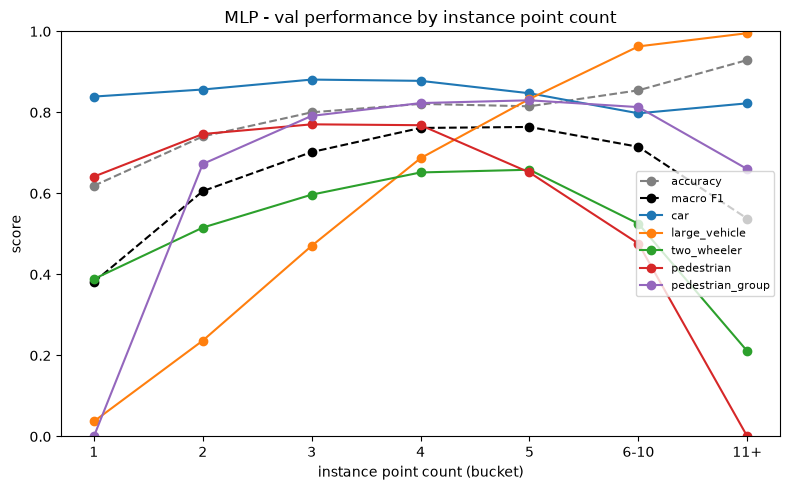

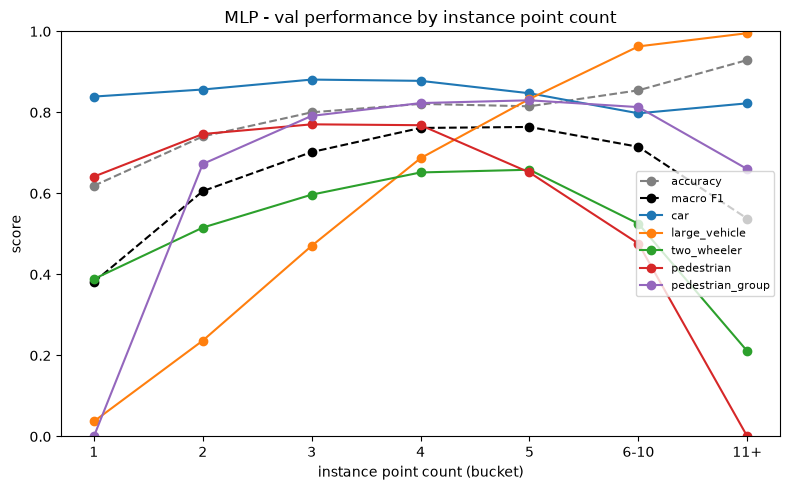

In [17]:
# one curve per class, overlaid - easier to read/explain than the table alone
plot_point_count_curve(point_count_summary)

A quarter of val is single-point instances, where the model is barely better than chance in macro-F1 terms (0.381). Macro F1 roughly doubles from 1 to 5 points (0.381 -> 0.764), same trained model throughout.

`large_vehicle` is the clearest case: f1 climbs almost monotonically, 0.037 (1 point) to 0.995 (11+ points), a question about size that's structurally unknowable from a single point, backed by real support (median 7 points/instance, 62% of val instances have 6+ points). `car` is the opposite pattern, flat and high throughout, a strong enough single-point signal (RCS/Doppler) that extra points barely matter, consistent with only 6% of `car` instances ever reaching 6+ points. `two_wheeler`/`pedestrian`/`pedestrian_group` rise then fall, a support/class-mix artifact rather than a real reversal: `evaluate_by_point_count` now reports per-class `support_<class>` per bucket, and `two_wheeler` support drops from 1,391 (bucket 1) to 242 (6-10) to 4 (11+); `pedestrian` drops from 6,318 to 49 to 0. `f1_pedestrian=0.000` at 11+ means zero real pedestrian instances there, not a model failure; `two_wheeler` at 11+ (4 instances) is noise, not a measurement. The tail buckets shift heavily toward `large_vehicle` instead (42% and 75% of the bucket).

Reconciling with the point-count feature tests above: those asked whether *telling* the network an instance's point count helps (it doesn't). This asks whether instances that structurally *have* more real points get classified better (they clearly do, for the classes with the support to show it). A count scalar doesn't add information the network can act on; more real points populating the histogram does.

**Finding:** sparsity is a real, large, and now directly demonstrated driver of the ceiling for classes that actually have point-count range to show it (`large_vehicle` above all). It doesn't act uniformly: `car` never needed the points, and `two_wheeler`/`pedestrian` simply don't have enough high-point instances in this dataset to say anything about how they'd behave with more. First evidence in this project that a change to what data goes in, rather than how it's summarized, could plausibly move the needle. Full writeup: `MLP_Decisions_and_Findings.md` section 10.

## Feature design: explicit statistics instead of histograms

Replaces the 65-dim histogram encoding entirely with 8 explicit per-instance statistics: `rcs` mean/median/std, `vr_compensated` mean/median (std dropped, `doppler_spread` already covers that), `radial` (new: `sqrt(x_rel^2+y_rel^2)`, rotation-invariant distance from centroid) std, `azimuth_sc` std, `doppler_spread` as-is. Defined in `scripts/mlp_variants.py`'s `stat_descriptors`.

/home/bruno/radar_machine_learning_ws/results/mlp/stat_descriptors/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/stat_descriptors/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/stat_descriptors/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.938   0.745  0.831    31055
large_vehicle         0.623   0.797  0.700     6247
two_wheeler           0.478   0.580  0.524     4629
pedestrian            0.505   0.759  0.607    11325
pedestrian_group      0.670   0.594  0.629    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/stat_descriptors/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/stat_descriptors/mlp_precision_recall_f1.png


,baseline,stat_descriptors,delta,split-choice spread (noise reference)
car,0.853802,0.830597,-0.023205,0.055956
large_vehicle,0.756059,0.699642,-0.056417,0.196742
two_wheeler,0.507601,0.523819,0.016218,0.385549
pedestrian,0.681956,0.606578,-0.075378,0.073356
pedestrian_group,0.632295,0.629320,-0.002975,0.116629


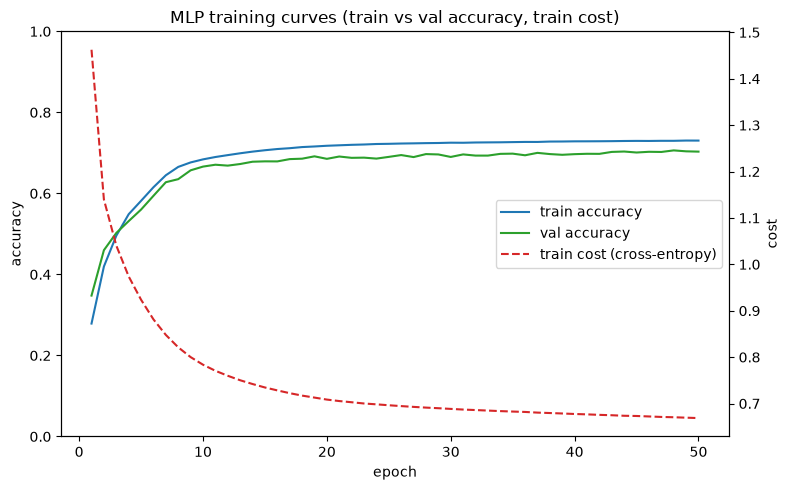

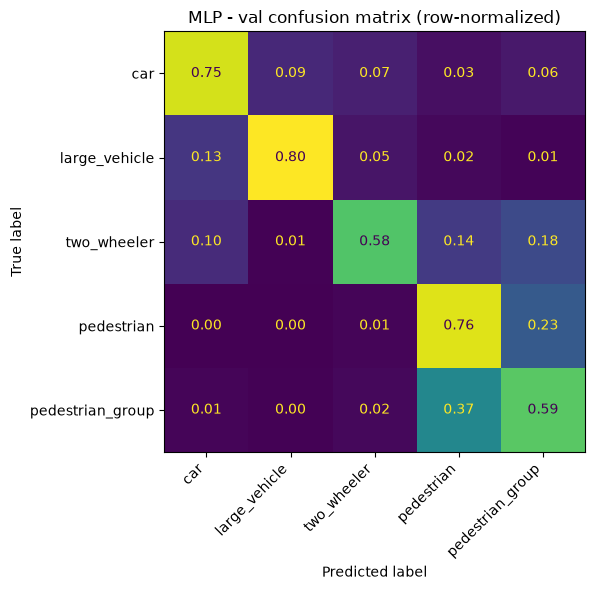

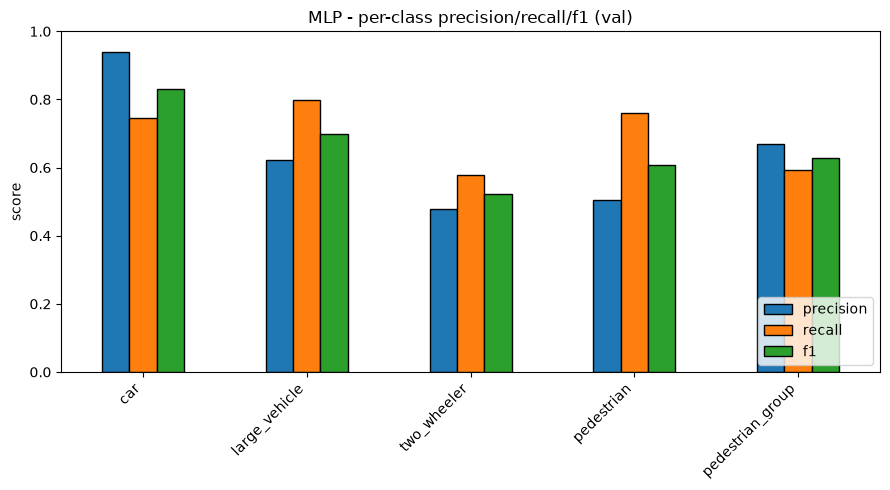

In [18]:
# cached, no retraining
_, _, stat_descriptors_metrics, _, _ = run_variant(df, "stat_descriptors")
pd.DataFrame({
    "baseline": baseline_metrics["f1"],
    "stat_descriptors": stat_descriptors_metrics["f1"],
    "delta": stat_descriptors_metrics["f1"] - baseline_metrics["f1"],
    "split-choice spread (noise reference)": split_spread,
})

Macro F1: `baseline` 0.686, `stat_descriptors` 0.658, a drop, not the usual within-noise flat line. All per-class deltas inside noise except `pedestrian` (-0.075 vs spread 0.073), the first delta in this program to land just outside its noise floor.

**Finding:** seventh axis landing at/inside the noise floor overall, but `pedestrian`'s borderline drop is worth watching in a direct confusion-matrix study. Full writeup: `MLP_Decisions_and_Findings.md` section 11.

## Feature design: bin edge placement (mean/std range, quantile bins)

Two tests, both otherwise identical to `baseline`, only how the 16 bin edges are placed changes. `gaussian_range`: still equal-width bins, but the outer range is `[mean-2std, mean+2std]` instead of decision 2's `[1st, 99th]` percentile. `quantile_bins`: a stronger, structurally different change, unequal-width bins, edges placed so each bin holds roughly equal training mass instead of equal range. `histogram_separability.fit_bin_edges`'s `range_method="gaussian"`/`"quantile"`, defined in `scripts/mlp_variants.py`'s `gaussian_range`/`quantile_bins`.

/home/bruno/radar_machine_learning_ws/results/mlp/gaussian_range/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/gaussian_range/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/gaussian_range/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.930   0.783  0.850    31055
large_vehicle         0.704   0.798  0.748     6247
two_wheeler           0.510   0.520  0.515     4629
pedestrian            0.539   0.893  0.672    11325
pedestrian_group      0.720   0.580  0.643    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/gaussian_range/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/gaussian_range/mlp_precision_recall_f1.png


,baseline,gaussian_range,delta,split-choice spread (noise reference)
car,0.853802,0.850295,-0.003507,0.055956
large_vehicle,0.756059,0.747919,-0.008140,0.196742
two_wheeler,0.507601,0.514818,0.007217,0.385549
pedestrian,0.681956,0.672116,-0.009839,0.073356
pedestrian_group,0.632295,0.642671,0.010377,0.116629


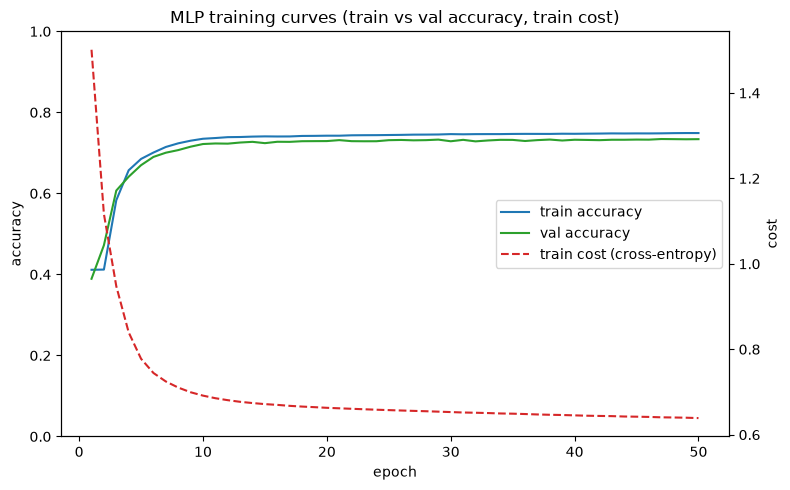

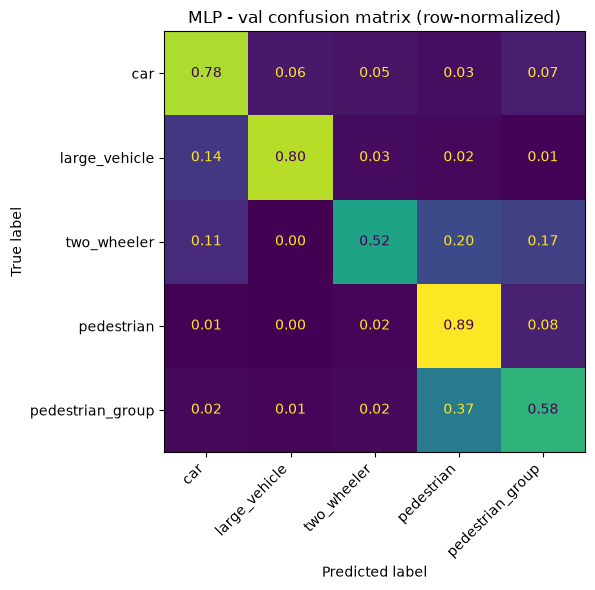

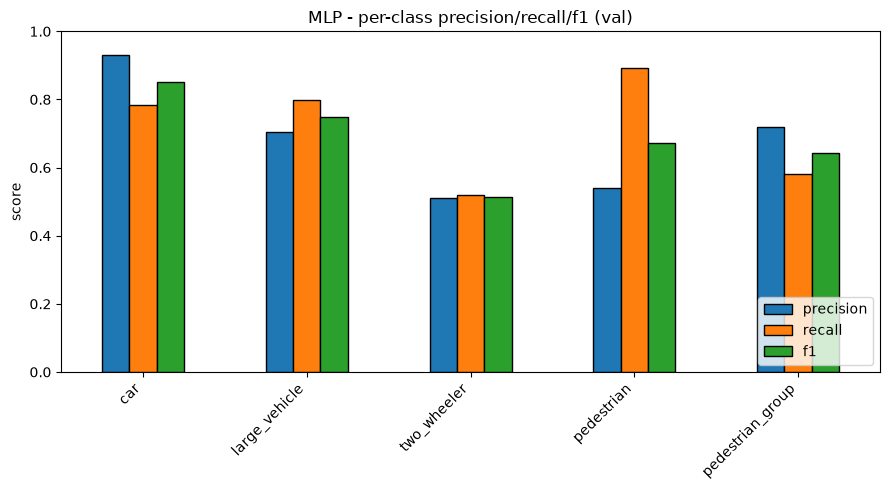

In [19]:
# cached, no retraining
_, _, gaussian_range_metrics, _, _ = run_variant(df, "gaussian_range")
pd.DataFrame({
    "baseline": baseline_metrics["f1"],
    "gaussian_range": gaussian_range_metrics["f1"],
    "delta": gaussian_range_metrics["f1"] - baseline_metrics["f1"],
    "split-choice spread (noise reference)": split_spread,
})

/home/bruno/radar_machine_learning_ws/results/mlp/quantile_bins/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/quantile_bins/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/quantile_bins/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.750  0.835    31055
large_vehicle         0.620   0.807  0.701     6247
two_wheeler           0.482   0.581  0.527     4629
pedestrian            0.563   0.855  0.679    11325
pedestrian_group      0.723   0.628  0.672    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/quantile_bins/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/quantile_bins/mlp_precision_recall_f1.png


,baseline,quantile_bins,delta,split-choice spread (noise reference)
car,0.853802,0.834792,-0.019010,0.055956
large_vehicle,0.756059,0.701217,-0.054841,0.196742
two_wheeler,0.507601,0.526769,0.019168,0.385549
pedestrian,0.681956,0.679272,-0.002684,0.073356
pedestrian_group,0.632295,0.672183,0.039888,0.116629


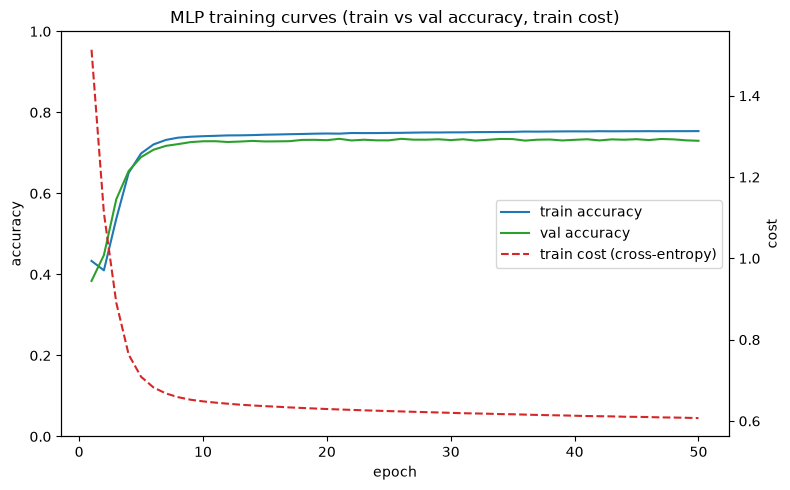

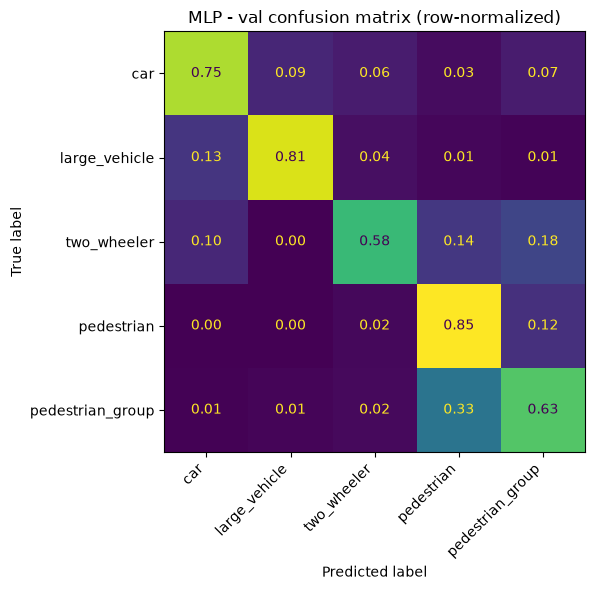

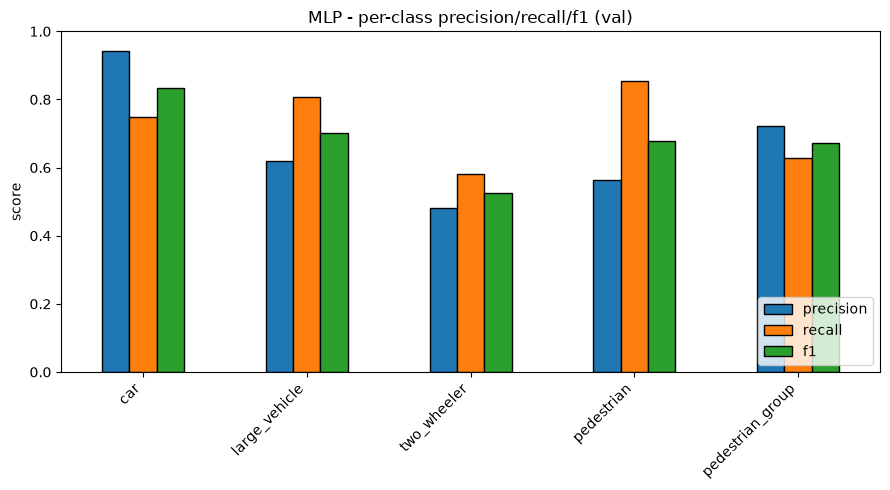

In [20]:
# cached, no retraining
_, _, quantile_bins_metrics, _, _ = run_variant(df, "quantile_bins")
pd.DataFrame({
    "baseline": baseline_metrics["f1"],
    "quantile_bins": quantile_bins_metrics["f1"],
    "delta": quantile_bins_metrics["f1"] - baseline_metrics["f1"],
    "split-choice spread (noise reference)": split_spread,
})

Macro F1: `baseline` 0.686, `gaussian_range` 0.686 (identical, tightest null in this program), `quantile_bins` 0.683, both inside noise per-class. `quantile_bins` also surfaced a real edge case: `x_rel`/`y_rel` each got a duplicate bin edge at exactly `0.0` (true by construction for single-point instances), permanently emptying one of 16 bins per feature. Didn't visibly hurt anything.

**Finding:** bin edge placement doesn't matter, even though it plausibly could have (it changes where a raw value maps to, not just how points aggregate). Consistent with the point count diagnostic: the ceiling is upstream of every encoding choice. Full writeup: `MLP_Decisions_and_Findings.md` section 12.

## Confusion matrix study: pedestrian/two_wheeler separability under sparsity

Direct diagnostic on the pedestrian/two_wheeler pair: is their confusion driven by the same sparsity ceiling the point count diagnostic found for `large_vehicle`, or something else? `separability_probe.run_probe` (class-weighted logistic regression + random forest, sequence-grouped held-out split, `[rcs, vr_compensated, x_extent, y_extent, doppler_spread]`, same feature set as the large_vehicle/truck/bus taxonomy probe used elsewhere in this project), run twice on just these two classes: once restricted to sparse instances (`n_points<=2`), once to dense ones (`n_points>=5`). No MLP retraining, a separate sklearn probe on a hand-built feature set. `scripts/pedestrian_separability.py`.

/home/bruno/radar_machine_learning_ws/results/data/doppler_spread_cache.parquet covers different sequences than requested, recomputing doppler_spread


Saved doppler_spread cache to /home/bruno/radar_machine_learning_ws/results/data/doppler_spread_cache.parquet



=== sparse regime (n_points <= 2) ===
label_name
pedestrian     65237
two_wheeler    19188



=== dense regime (n_points >= 5) ===
label_name
two_wheeler    4412
pedestrian     1788


macro_f1  pairwise_auc
regime model                                      
sparse logistic_regression  0.771122      0.805872
       random_forest        0.877336      0.920776
dense  logistic_regression  0.842235      0.944913
       random_forest        0.927162      0.980840

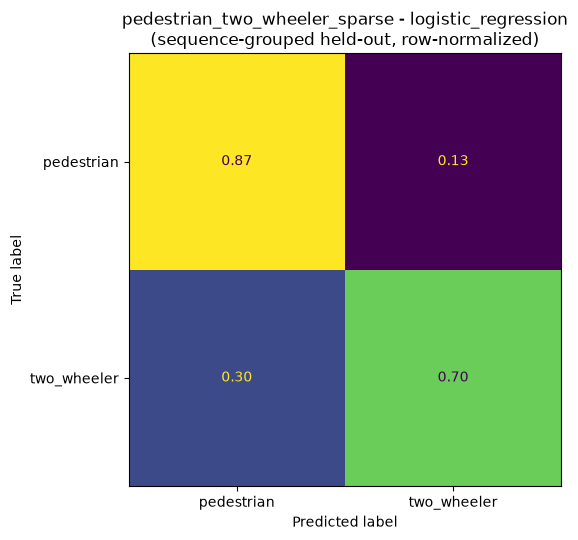

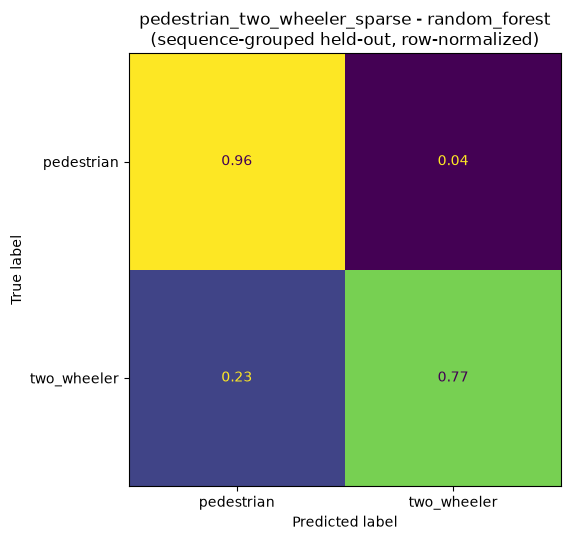

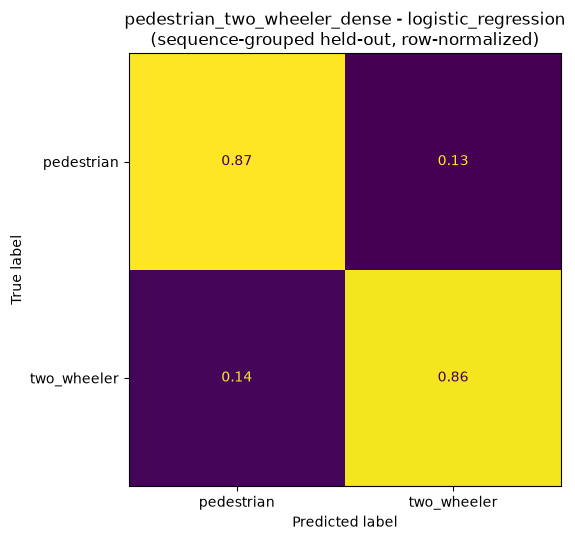

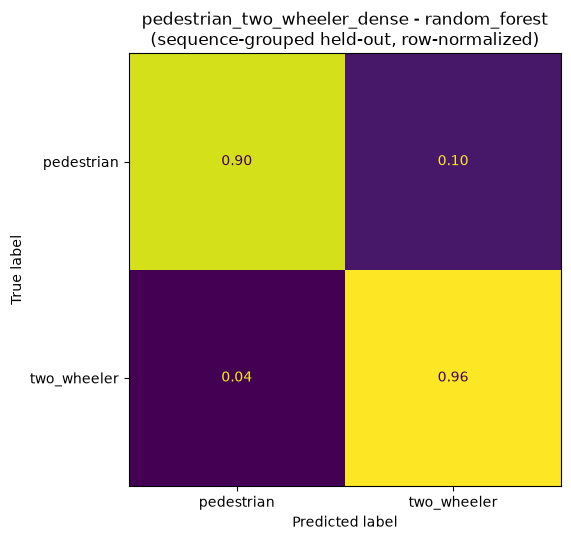

In [21]:
from pedestrian_separability import run_sparse_regime_probe, summarize_probe_results

# separability probe (LR + RF), not the MLP - restricted to sparse (n_points<=2) and dense
# (n_points>=5) pedestrian/two_wheeler instances. verbose=False since the table below covers it.
probe_results = run_sparse_regime_probe(df, verbose=False)
summarize_probe_results(probe_results)

Same direction as the point count diagnostic (sparse worse than dense), but a much smaller gap than `large_vehicle`/`car` showed there: LR pairwise AUC drops from 0.945 (dense) to 0.806 (sparse), still comfortably separable. Likely reason: `x_extent`/`y_extent` are trivially 0 at `n_points=1`, so separation here comes almost entirely from `rcs`/`vr_compensated`, both meaningful from a single point, unlike the size/extent signal `large_vehicle` needs several points to expose. Caveat: only 2.3% of pedestrian instances have `n_points>=5`, a small and likely non-representative subset.

**Finding:** pedestrian/two_wheeler confusion isn't primarily a sparsity problem the way `large_vehicle`/`car`'s is. This used a hand-built feature set, not the MLP's own encoding, so it speaks to whether separating signal exists in the data, not to why the trained MLP itself confuses this pair. Full writeup: `MLP_Decisions_and_Findings.md` section 13.

## Feature design: combined_features (everything, additive)

Every feature-design test above tried one representation change at a time, always inside noise. This tests something different: keep everything `baseline` already has and stack on top of it every other feature tried in this program, nothing removed. Histograms (16 bins each): `rcs`, `vr_compensated`, `x_rel`, `y_rel` (baseline's 4) plus `range_sc`, `azimuth_sc` (new, 96 dims). Unbinned scalars: `doppler_spread` (baseline's 1) plus `n_points`, `azimuth_extent`, `spatial_extent` (already built, unused until now) and `rcs_extent`, `range_extent` (new, same max-min-per-instance recipe as `azimuth_extent`). 102 dims total vs baseline's 65. Defined in `scripts/mlp_variants.py`'s `combined_features`.

/home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.947   0.794  0.864    31055
large_vehicle         0.668   0.819  0.736     6247
two_wheeler           0.510   0.666  0.578     4629
pedestrian            0.588   0.823  0.686    11325
pedestrian_group      0.752   0.653  0.699    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/combined_features/mlp_precision_recall_f1.png


,baseline,combined_features,delta,split-choice spread (noise reference)
car,0.853802,0.863793,0.009991,0.055956
large_vehicle,0.756059,0.736017,-0.020041,0.196742
two_wheeler,0.507601,0.577669,0.070069,0.385549
pedestrian,0.681956,0.685622,0.003666,0.073356
pedestrian_group,0.632295,0.699314,0.067019,0.116629


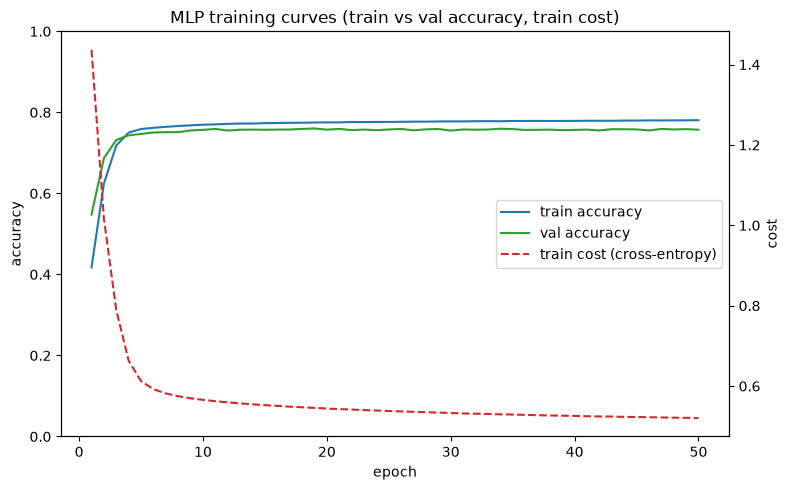

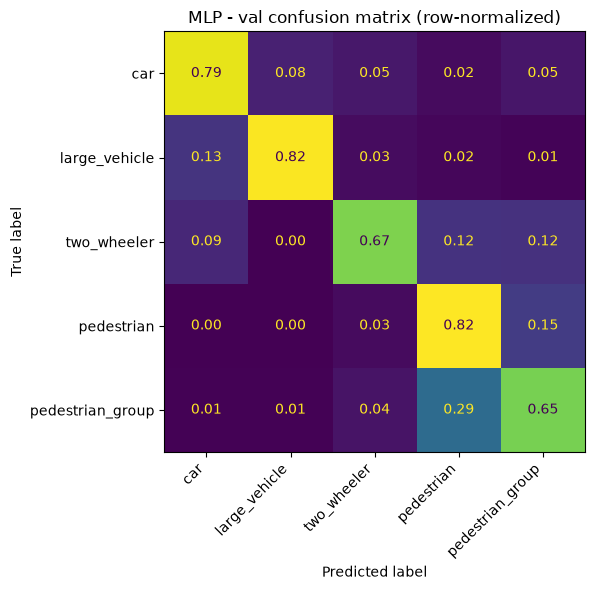

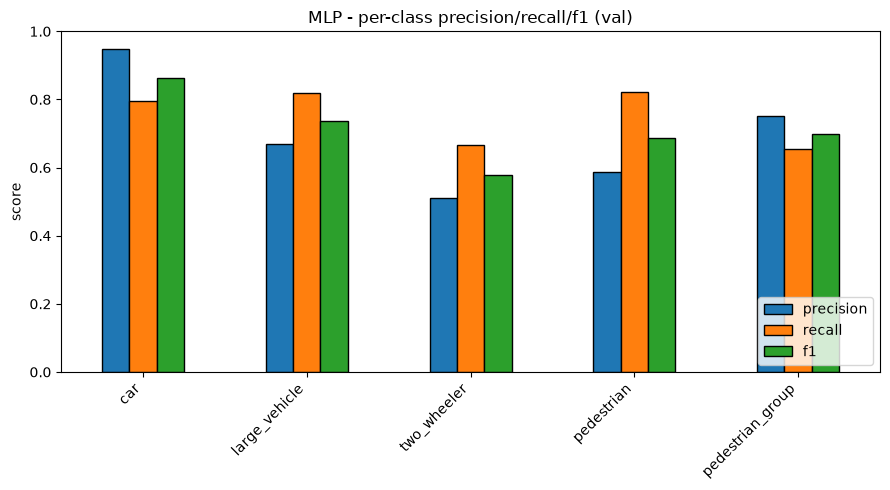

In [22]:
# cached, no retraining
_, _, combined_features_metrics, _, _ = run_variant(df, "combined_features")
pd.DataFrame({
    "baseline": baseline_metrics["f1"],
    "combined_features": combined_features_metrics["f1"],
    "delta": combined_features_metrics["f1"] - baseline_metrics["f1"],
    "split-choice spread (noise reference)": split_spread,
})

Single-split macro F1: `baseline` 0.686, `combined_features` 0.713 (+0.027) - the biggest single-split gain in this program, but by itself no more trustworthy than `range_sc`'s (+0.018) or `deep10`'s (+0.023), both of which the split-sensitivity check flattened to noise. Ran the same check here.

In [23]:
# loads cached fold results for both variants - no retraining. Split selection depends only on
# class/sequence composition, not feature choice, so fold i is the same split in both runs -
# a genuine paired comparison, not just two separate ranges.
baseline_fold_f1, ks_fold_f1, ks_fold_tw_f1 = [], [], []
for i in range(6):
    b = json.loads((MLP_DIR / "split_search" / f"fold_{i}" / "mlp_val_metrics.json").read_text())
    k = json.loads((MLP_DIR / "split_search_combined_features" / f"fold_{i}" / "mlp_val_metrics.json").read_text())
    baseline_fold_f1.append(sum(b[c]["f1"] for c in baseline_metrics.index) / len(baseline_metrics.index))
    ks_fold_f1.append(sum(k[c]["f1"] for c in baseline_metrics.index) / len(baseline_metrics.index))
    ks_fold_tw_f1.append((b["two_wheeler"]["f1"], k["two_wheeler"]["f1"]))

fold_compare = pd.DataFrame({
    "baseline_macro_f1": baseline_fold_f1,
    "combined_features_macro_f1": ks_fold_f1,
})
fold_compare["delta"] = fold_compare["combined_features_macro_f1"] - fold_compare["baseline_macro_f1"]
fold_compare

,baseline_macro_f1,combined_features_macro_f1,delta
0,0.678828,0.707528,0.028701
1,0.734235,0.775183,0.040948
2,0.700931,0.737515,0.036584
3,0.651298,0.701095,0.049797
4,0.695262,0.734277,0.039015
5,0.688433,0.706421,0.017988


In [24]:
# two_wheeler specifically - by far the largest split-choice spread of any class (0.386, from
# the split sensitivity table above), and the class this variant helps most
tw_df = pd.DataFrame(ks_fold_tw_f1, columns=["baseline_two_wheeler_f1", "combined_features_two_wheeler_f1"])
tw_df["delta"] = tw_df["combined_features_two_wheeler_f1"] - tw_df["baseline_two_wheeler_f1"]
print("baseline two_wheeler spread:", tw_df["baseline_two_wheeler_f1"].max() - tw_df["baseline_two_wheeler_f1"].min())
print("combined_features two_wheeler spread:", tw_df["combined_features_two_wheeler_f1"].max() - tw_df["combined_features_two_wheeler_f1"].min())
tw_df

baseline two_wheeler spread: 0.38554898089999995
combined_features two_wheeler spread: 0.27521299499999996


,baseline_two_wheeler_f1,combined_features_two_wheeler_f1,delta
0,0.581616,0.622848,0.041233
1,0.822681,0.843033,0.020352
2,0.528887,0.609037,0.080150
3,0.437132,0.567820,0.130688
4,0.552798,0.614045,0.061247
5,0.504682,0.571195,0.066513


`combined_features` wins every one of the 6 folds (+0.018 to +0.050, mean +0.036) - unlike `range_sc`/`deep10`, this survives the exact check that debunked those. First and only positive, cross-validated result in the whole program.

Sign test: if the two were truly equivalent, winning all 6 independent folds by chance has probability (1/2)^6 ≈ 1.6%, materially stronger than a single positive split. Caveat: folds share the same sequence pool and fixed test split, so this is strong evidence, not a certified p-value.

Per-class: `two_wheeler`/`pedestrian_group` account for essentially the whole gain (all individual deltas inside noise floors). Confirmed across all 6 folds for `two_wheeler` specifically, improves in every fold (+0.020 to +0.131, mean +0.067), the largest and most consistent per-class gain of any class, and its own fold-to-fold spread narrows too (0.386 -> 0.275). `large_vehicle`, the point-count diagnostic's clearest sparsity casualty, did not benefit, evidence this gain isn't rescuing sparse instances specifically.

Magnitude: the validated gain (+0.036) is roughly a tenth the size of the sparsity effect (macro F1 roughly doubling, 0.381 to 0.764, from 1 to 5 points). Reads as real, previously-unexploited signal in the richer feature combination, not a dent in the sparsity ceiling.

**Finding:** the null results above aren't wrong, each answered "does this one feature, alone, help" (no). This answers "do several together help" (yes, validated) - purely additive, unlike the earlier replacement-style tests, so nothing already pulling its weight competed for a slot. Full writeup: `MLP_Decisions_and_Findings.md` section 14.

### Which of the seven additions is actually doing the work?

Zero-out feature importance on the already-trained `combined_features` model (single val split, no retraining): zero one feature group's columns at a time, measure the macro F1 drop from the full 102-dim model. Fast diagnostic, not split-sensitivity-grade - single-split noise applies to the exact numbers, not the broad ranking.

In [25]:
import torch
from sklearn.metrics import f1_score
from mlp_classifier import MLP, DEVICE, prepare_split_features, MLP_CLASSES

ks_features = ["rcs", "vr_compensated", "x_rel", "y_rel", "range_sc", "azimuth_sc"]
ks_extra_features = ["doppler_spread", "n_points", "azimuth_extent", "spatial_extent", "rcs_extent", "range_extent"]

_, _, X_val_ks, y_val_ks, _, _, ks_feature_cols = prepare_split_features(
    df, classes=MLP_CLASSES, features=ks_features, extra_features=ks_extra_features
)

ks_model = MLP(input_dim=X_val_ks.shape[1], hidden_dim=16, num_classes=len(MLP_CLASSES), n_hidden_layers=2).to(DEVICE)
ks_model.load_state_dict(torch.load(MLP_DIR / "combined_features" / "mlp_model.pt", map_location=DEVICE))
ks_model.eval()

def ks_macro_f1(X):
    with torch.no_grad():
        pred = ks_model(torch.tensor(X, device=DEVICE)).argmax(dim=1).cpu().numpy()
    return f1_score(y_val_ks, pred, average="macro")

full_ks_f1 = ks_macro_f1(X_val_ks)

groups = {
    "vr_compensated (hist, baseline)": [c for c in ks_feature_cols if c.startswith("vr_compensated_bin")],
    "spatial_extent (scalar, added)": ["spatial_extent"],
    "rcs_extent (scalar, added)": ["rcs_extent"],
    "x_rel (hist, baseline)": [c for c in ks_feature_cols if c.startswith("x_rel_bin")],
    "rcs (hist, baseline)": [c for c in ks_feature_cols if c.startswith("rcs_bin")],
    "range_sc (hist, added)": [c for c in ks_feature_cols if c.startswith("range_sc_bin")],
    "azimuth_sc (hist, added)": [c for c in ks_feature_cols if c.startswith("azimuth_sc_bin")],
    "y_rel (hist, baseline)": [c for c in ks_feature_cols if c.startswith("y_rel_bin")],
    "n_points (scalar, added)": ["n_points"],
    "range_extent (scalar, added)": ["range_extent"],
    "doppler_spread (scalar, baseline)": ["doppler_spread"],
    "azimuth_extent (scalar, added)": ["azimuth_extent"],
}
col_idx = {c: i for i, c in enumerate(ks_feature_cols)}
rows = []
for name, cols in groups.items():
    idx = [col_idx[c] for c in cols]
    X_zeroed = X_val_ks.copy()
    X_zeroed[:, idx] = 0.0
    f1 = ks_macro_f1(X_zeroed)
    rows.append({"feature group": name, "dims": len(idx), "macro_f1_zeroed": f1, "drop": f1 - full_ks_f1})

importance_df = pd.DataFrame(rows).sort_values("drop").reset_index(drop=True)
print(f"full (102-dim) macro F1: {full_ks_f1:.4f}")
importance_df

full (102-dim) macro F1: 0.7125


,feature group,dims,macro_f1_zeroed,drop
0,"vr_compensated (hist, baseline)",16,0.381197,-0.331286
1,"spatial_extent (scalar, added)",1,0.632051,-0.080432
2,"rcs_extent (scalar, added)",1,0.667096,-0.045387
3,"x_rel (hist, baseline)",16,0.672341,-0.040142
4,"rcs (hist, baseline)",16,0.678992,-0.033491
5,"range_sc (hist, added)",16,0.682376,-0.030108
6,"azimuth_sc (hist, added)",16,0.685175,-0.027308
7,"y_rel (hist, baseline)",16,0.694721,-0.017762
8,"n_points (scalar, added)",1,0.696067,-0.016416
9,"range_extent (scalar, added)",1,0.705583,-0.006900


`vr_compensated` dwarfs everything (raw velocity information nothing else substitutes for). Among the seven additions specifically, importance is concentrated in two, both single scalars: `spatial_extent` and `rcs_extent`, each outperforming several 16-dim histogram blocks. The rest (`range_sc`, `azimuth_sc`, `n_points`, `range_extent`, `azimuth_extent`) are minor to negligible individually.

Resolves the addition-vs-replacement puzzle from the `spatial_extent` section above with direct evidence: tested as a *replacement* for `x_rel`/`y_rel` it came out null, not because it's useless, but because it's roughly as useful as what it replaced, so swapping nets out to nothing. `rcs_extent` is the more novel finding - never tested standalone before this variant, and the first evidence RCS's own within-instance spread carries signal independent of its central tendency. Full writeup: `MLP_Decisions_and_Findings.md` section 14a.

### Do the two most load-bearing additions reproduce the gain alone?

Isolate the two zero-out standouts as their own minimal additions to `baseline`. `rcs_extent_only`: baseline's 4 histograms unchanged, `rcs_extent` added alongside `doppler_spread`. `spatial_extent_added`: baseline's `x_rel`/`y_rel` kept (unlike the earlier `spatial_extent` section, which replaced them), `spatial_extent` added alongside `doppler_spread`.

/home/bruno/radar_machine_learning_ws/results/mlp/rcs_extent_only/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/rcs_extent_only/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/rcs_extent_only/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.942   0.785  0.856    31055
large_vehicle         0.707   0.800  0.751     6247
two_wheeler           0.473   0.561  0.514     4629
pedestrian            0.539   0.899  0.674    11325
pedestrian_group      0.751   0.579  0.654    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/rcs_extent_only/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/rcs_extent_only/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent_added/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent_added/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent_added/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.939   0.796  0.862    31055
large_vehicle         0.741   0.804  0.771     6247
two_wheeler           0.481   0.553  0.514     4629
pedestrian            0.556   0.906  0.689    11325
pedestrian_group      0.735   0.586  0.652    17858


Saved /home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent_added/mlp_confusion_matrix.png
Saved /home/bruno/radar_machine_learning_ws/results/mlp/spatial_extent_added/mlp_precision_recall_f1.png


,baseline,rcs_extent_only,spatial_extent_added
car,0.853802,0.856365,0.861983
large_vehicle,0.756059,0.750507,0.771380
two_wheeler,0.507601,0.513636,0.514223
pedestrian,0.681956,0.673946,0.689199
pedestrian_group,0.632295,0.654084,0.652113


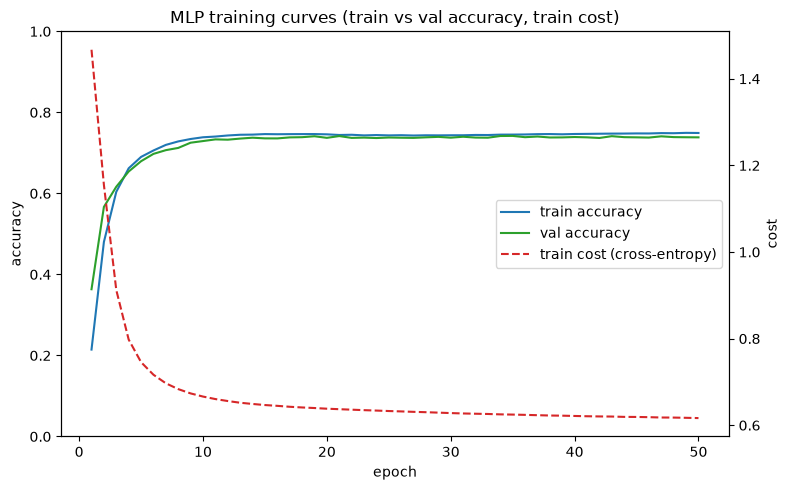

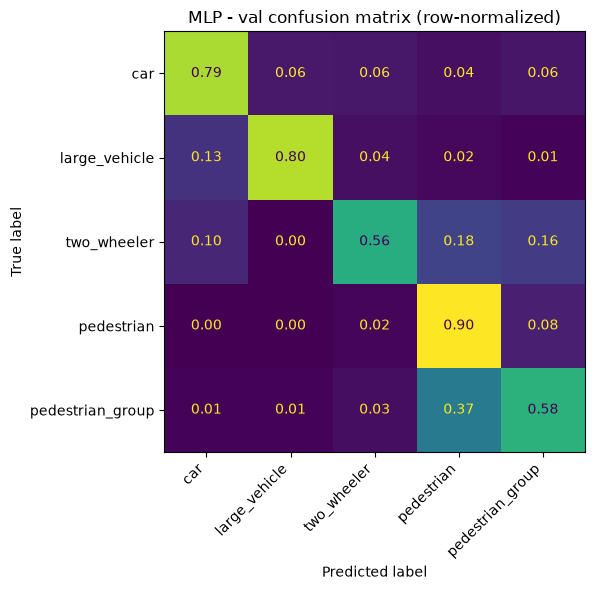

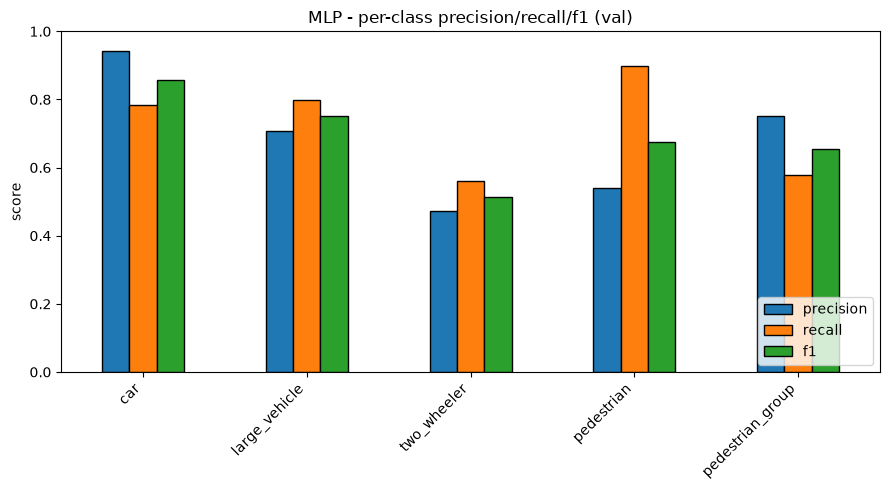

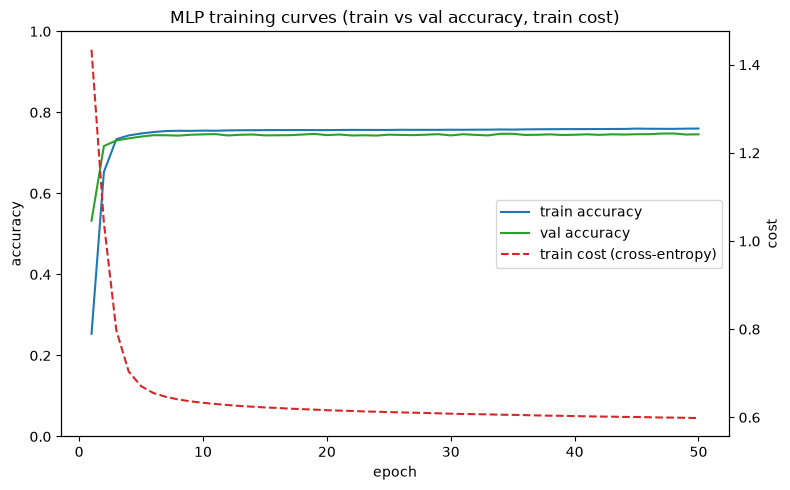

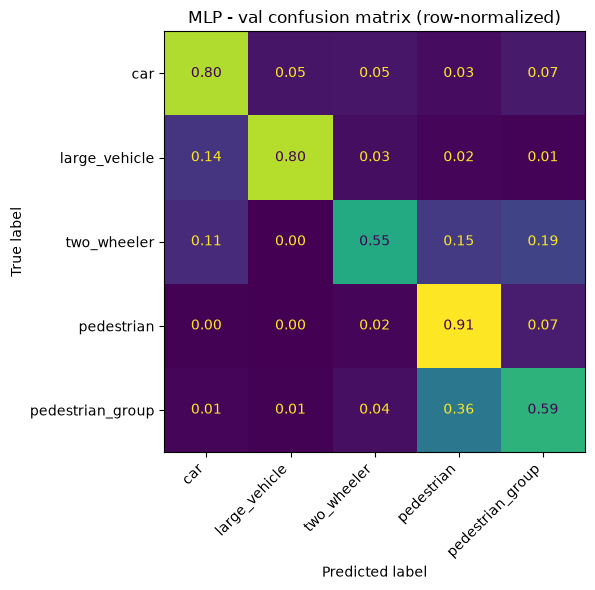

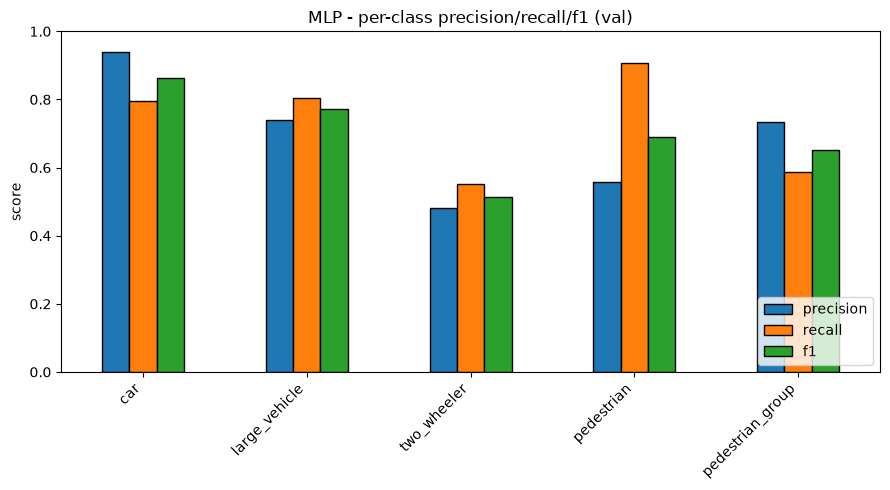

In [26]:
# both cached, no retraining
_, _, rcs_extent_only_metrics, _, _ = run_variant(df, "rcs_extent_only")
_, _, spatial_extent_added_metrics, _, _ = run_variant(df, "spatial_extent_added")
pd.DataFrame({
    "baseline": baseline_metrics["f1"],
    "rcs_extent_only": rcs_extent_only_metrics["f1"],
    "spatial_extent_added": spatial_extent_added_metrics["f1"],
})

Macro F1: `baseline` 0.686, `rcs_extent_only` 0.690 (+0.004), `spatial_extent_added` 0.698 (+0.012). Neither comes close to `combined_features`'s single-split gain (+0.027) or validated 6-fold mean (+0.036), even summed (+0.016) they cover less than half of it.

**Finding:** high zero-out importance in context doesn't mean high standalone value, direct demonstration of the difference. The gap points to a real interaction across several additions, not one or two features. Neither result clears the noise floor alone, so not run through split-sensitivity. Full writeup: `MLP_Decisions_and_Findings.md` section 14b.

## Summary

| variant | macro F1 | notes |
|---|---|---|
| `bus_separate` (6 classes) | 0.611 | original taxonomy, superseded |
| `baseline` (5 classes, bus merged) | 0.686 | standing model |
| `truck_separate` (7 classes) | 0.541 | confirms truck merge was correct |
| `range_sc` | 0.704 | looked better, confirmed noise (see split sensitivity) |
| `bs32` | 0.687 | no real difference from baseline |
| `hidden8`/`hidden32`/`hidden64` | 0.688 / 0.688 / 0.688 | no capacity effect, feature ceiling not model ceiling |
| `deep10` (10 hidden layers) | 0.709 | looked better, confirmed noise (per-class deltas inside split-choice spread) |
| `n_points` / `raw_counts` | 0.692 / 0.690 | point count, explicit or implicit, both inside noise |
| `spatial_extent` / `azimuth_extent` | 0.690 / 0.696 | orientation-robust / angular features, both inside noise |
| `stat_descriptors` (8 explicit stats, no histograms) | 0.658 | a drop; `pedestrian` just outside its noise spread, everything else inside |
| `gaussian_range` (mean/std bin range vs percentile) | 0.686 | identical to baseline, tightest null in this program |
| `quantile_bins` (density-adaptive, unequal-width bins) | 0.683 | also null, stronger version of the bin-placement idea, same result |
| split sensitivity, 6 valid splits | 0.651 - 0.734 | noise floor for any single-split comparison here |
| split sensitivity, spatial_extent features | 0.655 - 0.745 | same noise floor check, different feature set - essentially unchanged |
| pedestrian/two_wheeler separability probe (not an MLP variant) | LR AUC 0.806 (sparse) / 0.945 (dense) | confusion isn't primarily sparsity-driven for this pair, unlike `large_vehicle`/`car` |
| `combined_features` (everything, additive, 102 dims) | 0.713 (single split), +0.036 validated mean over 6 folds | **first validated positive result in the program** - wins every fold, concentrated in `two_wheeler`/`pedestrian_group`, ~10x smaller than the sparsity effect |
| `rcs_extent_only` / `spatial_extent_added` | 0.690 / 0.698 | the two zero-out standouts tested alone - neither reproduces the gain, points to a real interaction |

Standing model: `baseline`, 5 classes, `BATCH_SIZE=128`, `EPOCHS=50`, `HIDDEN_DIM=16`, 2 hidden layers, `doppler_spread` feature set. Anything smaller than roughly a 3 point macro F1 gap shouldn't be trusted from a single split - `combined_features` is the one exception in this program, confirmed via the 6-fold split-sensitivity check rather than trusted on a single split.

Full writeup, reasoning, and the general lesson on split sensitivity: `MLP_Decisions_and_Findings.md`.